# Switch Transformer 单层性能瓶颈分析（MoE vs Non-MoE）

本分析基于 `outputs/final1/static_8_8_8` 的实验结果，验证：
1. MoE 层是否在 stall cycles 上显著高于其它子模块。
2. MoE 层是否存在更明显的 bank 利用不均衡。
3. 内存访问（bank conflict）对整体性能的影响程度。

若 MoE 在 stall 和 bank 不均衡均显著更高，则可判定 memory bottleneck 主要集中在 MoE 层。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

base = "outputs/final4/static_8_8_8"
compute = pd.read_csv(f"{base}/COMPUTE_REPORT.csv")
bank = pd.read_csv(f"{base}/BANK_MODEL_REPORT.csv")

# 清理列名中多余空格和末尾逗号
compute.columns = compute.columns.str.strip().str.rstrip(",")
bank.columns = bank.columns.str.strip().str.rstrip(",")

# 关键数值列转为数值类型
compute_numeric_cols = [
    "LayerID", "Total Cycles", "Stall Cycles", "Overall Util %", "Mapping Efficiency %", "Compute Util %"
]
bank_numeric_cols = [
    "LayerID",
    "ifmap_capacity_utilization", "filter_capacity_utilization", "ofmap_capacity_utilization",
    "ifmap_bank_conflict_delay", "filter_bank_conflict_delay", "ofmap_bank_conflict_delay",
    "total_bank_conflict_delay", "total_cycles", "stall_cycles_due_to_bank_conflict"
]

for c in compute_numeric_cols:
    compute[c] = pd.to_numeric(compute[c], errors="coerce")
for c in bank_numeric_cols:
    bank[c] = pd.to_numeric(bank[c], errors="coerce")

# 合并两个报告
df = compute.merge(bank, on="LayerID", how="inner", suffixes=("_compute", "_bank"))

# LayerID 对应 Switch Transformer 子模块
layer_names = {
    0: "Attn_Q_proj",
    1: "Attn_K_proj",
    2: "Attn_V_proj",
    3: "QKT_head",
    4: "QKTV_head",
    5: "Attn_O_proj",
    6: "Router_logits",
    7: "MoE-E0-FF1",
    8: "MoE-E0-FF2",
    9: "MoE-E1-FF1",
    10: "MoE-E1-FF2",
    11: "MoE-E2-FF1",
    12: "MoE-E2-FF2",
    13: "MoE-E3-FF1",
    14: "MoE-E3-FF2",
    15: "MoE-E4-FF1",
    16: "MoE-E4-FF2",
    17: "MoE-E5-FF1",
    18: "MoE-E5-FF2",
    19: "MoE-E6-FF1",
    20: "MoE-E6-FF2",
    21: "MoE-E7-FF1",
    22: "MoE-E7-FF2",
}

df["LayerName"] = df["LayerID"].map(layer_names)
df["ModuleType"] = np.where(df["LayerName"].str.startswith("MoE"), "MoE", "Non-MoE")

# 关键指标
df["StallRatio"] = df["Stall Cycles"] / df["Total Cycles"]
util_cols = ["ifmap_capacity_utilization", "filter_capacity_utilization", "ofmap_capacity_utilization"]
df["BankImbalance"] = df[util_cols].max(axis=1) - df[util_cols].min(axis=1)
df["BankConflictStallShare"] = df["stall_cycles_due_to_bank_conflict"] / df["Stall Cycles"]

# 汇总统计
group_mean = df.groupby("ModuleType")[["StallRatio", "BankImbalance", "BankConflictStallShare"]].mean()
cycle_sum = df.groupby("ModuleType")[["Total Cycles", "Stall Cycles"]].sum()

total_stall = df["Stall Cycles"].sum()
moe_stall = cycle_sum.loc["MoE", "Stall Cycles"]
moe_stall_share = moe_stall / total_stall

print("=== 模块均值对比（MoE vs Non-MoE）===")
display(group_mean)
print("\n=== 模块总量对比（cycles）===")
display(cycle_sum)
print(f"\nMoE 对总 stall cycles 的贡献占比: {moe_stall_share:.2%}")

df[["LayerID", "LayerName", "ModuleType", "Total Cycles", "Stall Cycles", "StallRatio", "BankImbalance", "BankConflictStallShare"]]

=== 模块均值对比（MoE vs Non-MoE）===


,StallRatio,BankImbalance,BankConflictStallShare
ModuleType,,,
MoE,0.829844,10.603271,1.0
Non-MoE,0.800403,8.200893,1.0



=== 模块总量对比（cycles）===


,Total Cycles,Stall Cycles
ModuleType,,
MoE,1870007,1549983
Non-MoE,394594,320565



MoE 对总 stall cycles 的贡献占比: 82.86%


,LayerID,LayerName,ModuleType,Total Cycles,Stall Cycles,StallRatio,BankImbalance,BankConflictStallShare
0,0,Attn_Q_proj,Non-MoE,85175,69120,0.811506,9.000000,1.0
1,1,Attn_K_proj,Non-MoE,85175,69120,0.811506,9.000000,1.0
2,2,Attn_V_proj,Non-MoE,85175,69120,0.811506,9.000000,1.0
3,3,QKT_head,Non-MoE,26967,23400,0.867727,15.500000,1.0
4,4,QKTV_head,Non-MoE,18525,14958,0.807449,3.000000,1.0
5,5,Attn_O_proj,Non-MoE,85175,69120,0.811506,9.000000,1.0
6,6,Router_logits,Non-MoE,8402,5727,0.681623,2.906250,1.0
7,7,MoE-E0-FF1,MoE,210680,174717,0.829300,19.875000,1.0
8,8,MoE-E0-FF2,MoE,206711,170748,0.826023,18.750000,1.0
9,9,MoE-E1-FF1,MoE,25115,20832,0.829464,1.687500,1.0


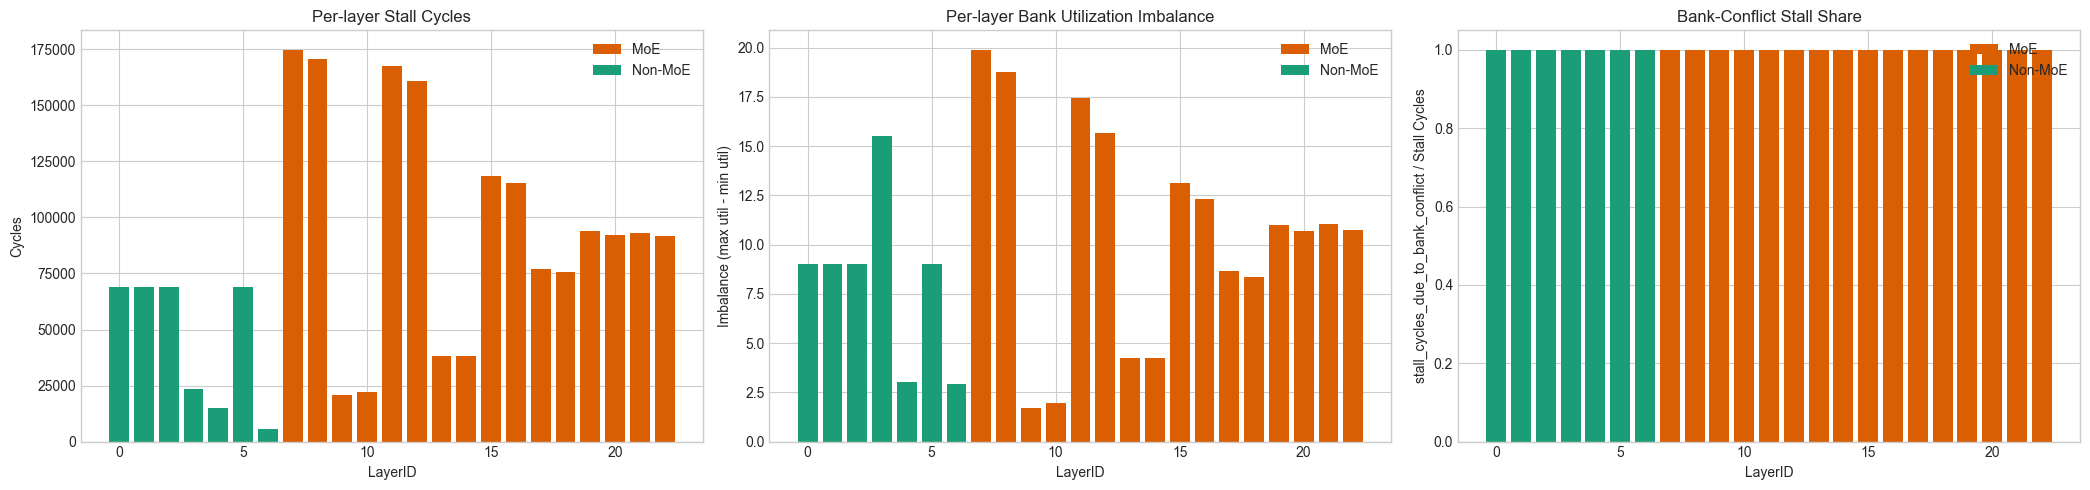

=== 自动结论判定 ===
MoE 平均 StallCycles / Non-MoE 平均 StallCycles = 2.12x
MoE 平均 BankImbalance / Non-MoE 平均 BankImbalance = 1.29x
MoE 对总 Stall Cycles 贡献占比 = 82.86%
全层平均 BankConflictStallShare = 100.00%

结论: MoE 层在 stall cycles 与 bank 利用不均衡上均显著高于其它层，且 stall 几乎完全由 bank conflict 驱动。
可判定系统主要 memory bottleneck 集中在 MoE 层，后续实验应聚焦 MoE 层展开。


In [2]:
# 图1: 各层 Stall Cycles（按模块类型着色）
plot_df = df.sort_values("LayerID").copy()
colors = plot_df["ModuleType"].map({"MoE": "#d95f02", "Non-MoE": "#1b9e77"})

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

axes[0].bar(plot_df["LayerID"], plot_df["Stall Cycles"], color=colors)
axes[0].set_title("Per-layer Stall Cycles")
axes[0].set_xlabel("LayerID")
axes[0].set_ylabel("Cycles")

# 图2: 各层 Bank 利用不均衡度 (max-min)
axes[1].bar(plot_df["LayerID"], plot_df["BankImbalance"], color=colors)
axes[1].set_title("Per-layer Bank Utilization Imbalance")
axes[1].set_xlabel("LayerID")
axes[1].set_ylabel("Imbalance (max util - min util)")

# 图3: 内存相关 stall 占比（bank conflict 导致）
axes[2].bar(plot_df["LayerID"], plot_df["BankConflictStallShare"], color=colors)
axes[2].set_title("Bank-Conflict Stall Share")
axes[2].set_xlabel("LayerID")
axes[2].set_ylabel("stall_cycles_due_to_bank_conflict / Stall Cycles")
axes[2].set_ylim(0, 1.05)

# 自定义图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d95f02", label="MoE"),
    Patch(facecolor="#1b9e77", label="Non-MoE")
]
for ax in axes:
    ax.legend(handles=legend_elements, loc="best")

plt.tight_layout()
plt.show()

# 结论判定（按你的实验口径：stall cycles 绝对量 + bank 不均衡）
moe = df[df["ModuleType"] == "MoE"]
non_moe = df[df["ModuleType"] == "Non-MoE"]

moe_stall_mean = moe["Stall Cycles"].mean()
non_moe_stall_mean = non_moe["Stall Cycles"].mean()
stall_cycles_gap = moe_stall_mean / non_moe_stall_mean

moe_imbalance_mean = moe["BankImbalance"].mean()
non_moe_imbalance_mean = non_moe["BankImbalance"].mean()
imbalance_gap = moe_imbalance_mean / non_moe_imbalance_mean

moe_stall_share = moe["Stall Cycles"].sum() / df["Stall Cycles"].sum()
mem_impact = df["BankConflictStallShare"].mean()

print("=== 自动结论判定 ===")
print(f"MoE 平均 StallCycles / Non-MoE 平均 StallCycles = {stall_cycles_gap:.2f}x")
print(f"MoE 平均 BankImbalance / Non-MoE 平均 BankImbalance = {imbalance_gap:.2f}x")
print(f"MoE 对总 Stall Cycles 贡献占比 = {moe_stall_share:.2%}")
print(f"全层平均 BankConflictStallShare = {mem_impact:.2%}")

is_moe_stall_higher = stall_cycles_gap > 1.50
is_moe_imbalance_higher = imbalance_gap > 1.20
is_moe_dominant_stall = moe_stall_share > 0.50
is_memory_dominant = mem_impact > 0.90

if is_moe_stall_higher and is_moe_imbalance_higher and is_moe_dominant_stall and is_memory_dominant:
    print("\n结论: MoE 层在 stall cycles 与 bank 利用不均衡上均显著高于其它层，且 stall 几乎完全由 bank conflict 驱动。")
    print("可判定系统主要 memory bottleneck 集中在 MoE 层，后续实验应聚焦 MoE 层展开。")
else:
    print("\n结论: 当前数据只部分支持 MoE 主导 bottleneck，建议增加不同 bank 配置与负载下的验证。")

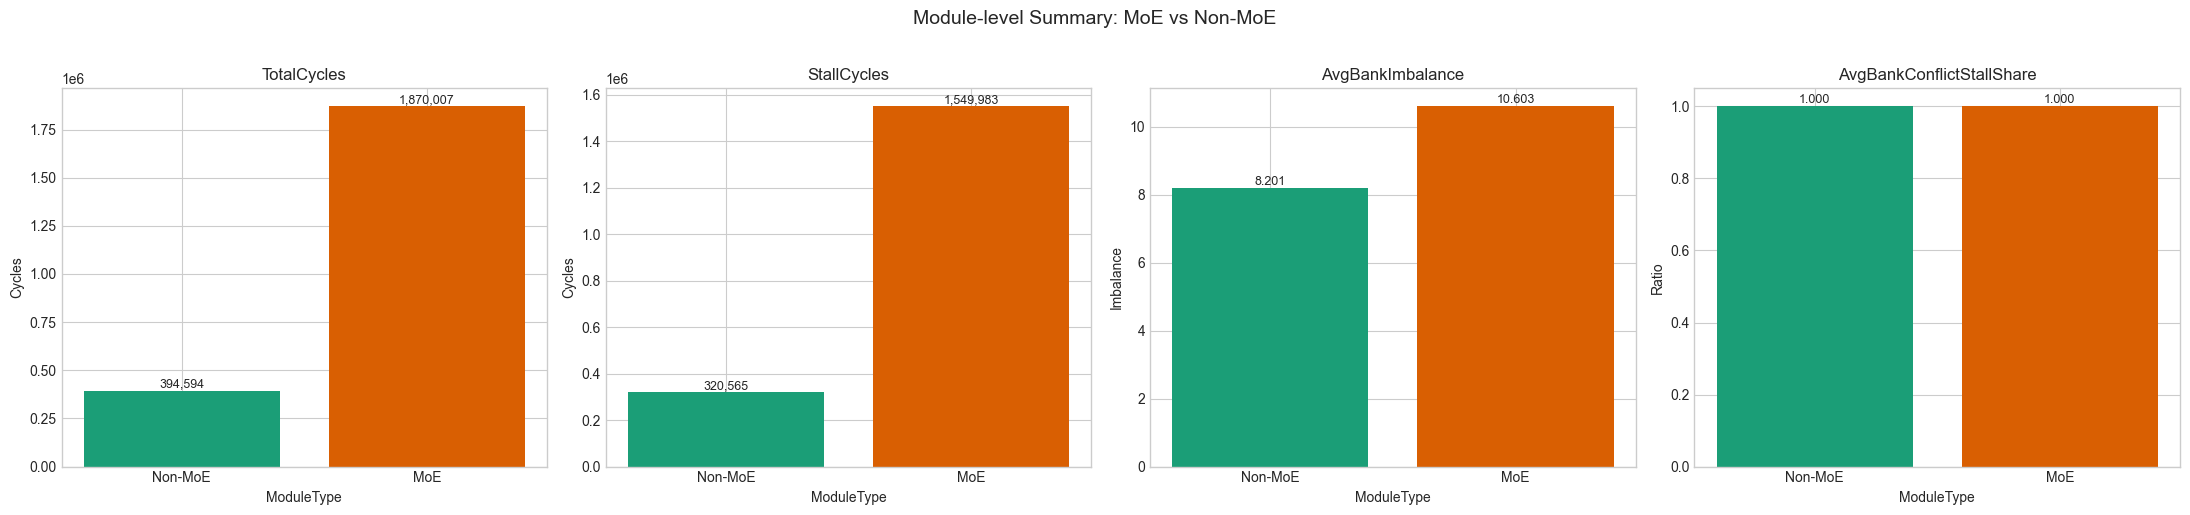

,ModuleType,TotalCycles,StallCycles,AvgBankImbalance,AvgBankConflictStallShare
0,MoE,1870007,1549983,10.603271,1.0
1,Non-MoE,394594,320565,8.200893,1.0


In [3]:
# 模块级汇总柱状图（MoE vs Non-MoE）
if "df" not in globals():
    raise RuntimeError("请先运行前面的数据准备单元（Cell 2）。")

module_summary = df.groupby("ModuleType").agg(
    TotalCycles=("Total Cycles", "sum"),
    StallCycles=("Stall Cycles", "sum"),
    AvgBankImbalance=("BankImbalance", "mean"),
    AvgBankConflictStallShare=("BankConflictStallShare", "mean"),
).reset_index()

plot_summary = module_summary.melt(
    id_vars="ModuleType",
    value_vars=["TotalCycles", "StallCycles", "AvgBankImbalance", "AvgBankConflictStallShare"],
    var_name="Metric",
    value_name="Value",
)

metric_order = ["TotalCycles", "StallCycles", "AvgBankImbalance", "AvgBankConflictStallShare"]
module_order = ["Non-MoE", "MoE"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
color_map = {"MoE": "#d95f02", "Non-MoE": "#1b9e77"}

for i, metric in enumerate(metric_order):
    ax = axes[i]
    sub = plot_summary[plot_summary["Metric"] == metric].copy()
    sub["ModuleType"] = pd.Categorical(sub["ModuleType"], categories=module_order, ordered=True)
    sub = sub.sort_values("ModuleType")

    ax.bar(sub["ModuleType"], sub["Value"], color=[color_map[m] for m in sub["ModuleType"]])
    ax.set_title(metric)
    ax.set_xlabel("ModuleType")

    if metric in ["TotalCycles", "StallCycles"]:
        ax.set_ylabel("Cycles")
    elif metric == "AvgBankImbalance":
        ax.set_ylabel("Imbalance")
    else:
        ax.set_ylabel("Ratio")
        ax.set_ylim(0, 1.05)

    for x, y in zip(sub["ModuleType"], sub["Value"]):
        if metric in ["TotalCycles", "StallCycles"]:
            label = f"{y:,.0f}"
        else:
            label = f"{y:.3f}"
        ax.text(x, y, label, ha="center", va="bottom", fontsize=9)

fig.suptitle("Module-level Summary: MoE vs Non-MoE", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

module_summary

## MoE层静态Bank比例敏感性分析（新增）

仅分析 MoE 层（LayerID 7-14），比较不同静态 bank 分配比例下的性能差异，验证静态资源供需失配是否是主要瓶颈来源。



=== MoE静态分配敏感性汇总 ===


,ratio,mismatch_index,avg_imbalance,moe_total_cycles,moe_total_cycles_norm,moe_stall_cycles,moe_stall_ratio,bank_conflict_stall_share
0,2:11:11,0.431339,7.075462,1159208,1.181794,839184,0.723929,1.0
1,3:3:18,0.759804,29.266927,1875593,1.912138,1555569,0.829374,1.0
2,3:18:3,0.141196,6.220703,1358756,1.385231,1038732,0.764473,1.0
3,7:7:10,0.589586,12.206083,1029869,1.049935,709845,0.689258,1.0
4,7:10:7,0.464586,8.309096,984665,1.003851,664641,0.674992,1.0
5,8:2:14,0.797919,44.479980,1865477,1.901825,1545453,0.828449,1.0
6,8:8:8,0.547919,10.603271,1870007,1.906443,1549983,0.828865,1.0
7,8:14:2,0.306339,10.723807,980888,1.000000,660864,0.673741,1.0
8,10:7:7,0.589586,12.330385,1021859,1.041769,701835,0.686822,1.0
9,11:2:11,0.797919,44.529652,1870649,1.907097,1550625,0.828924,1.0


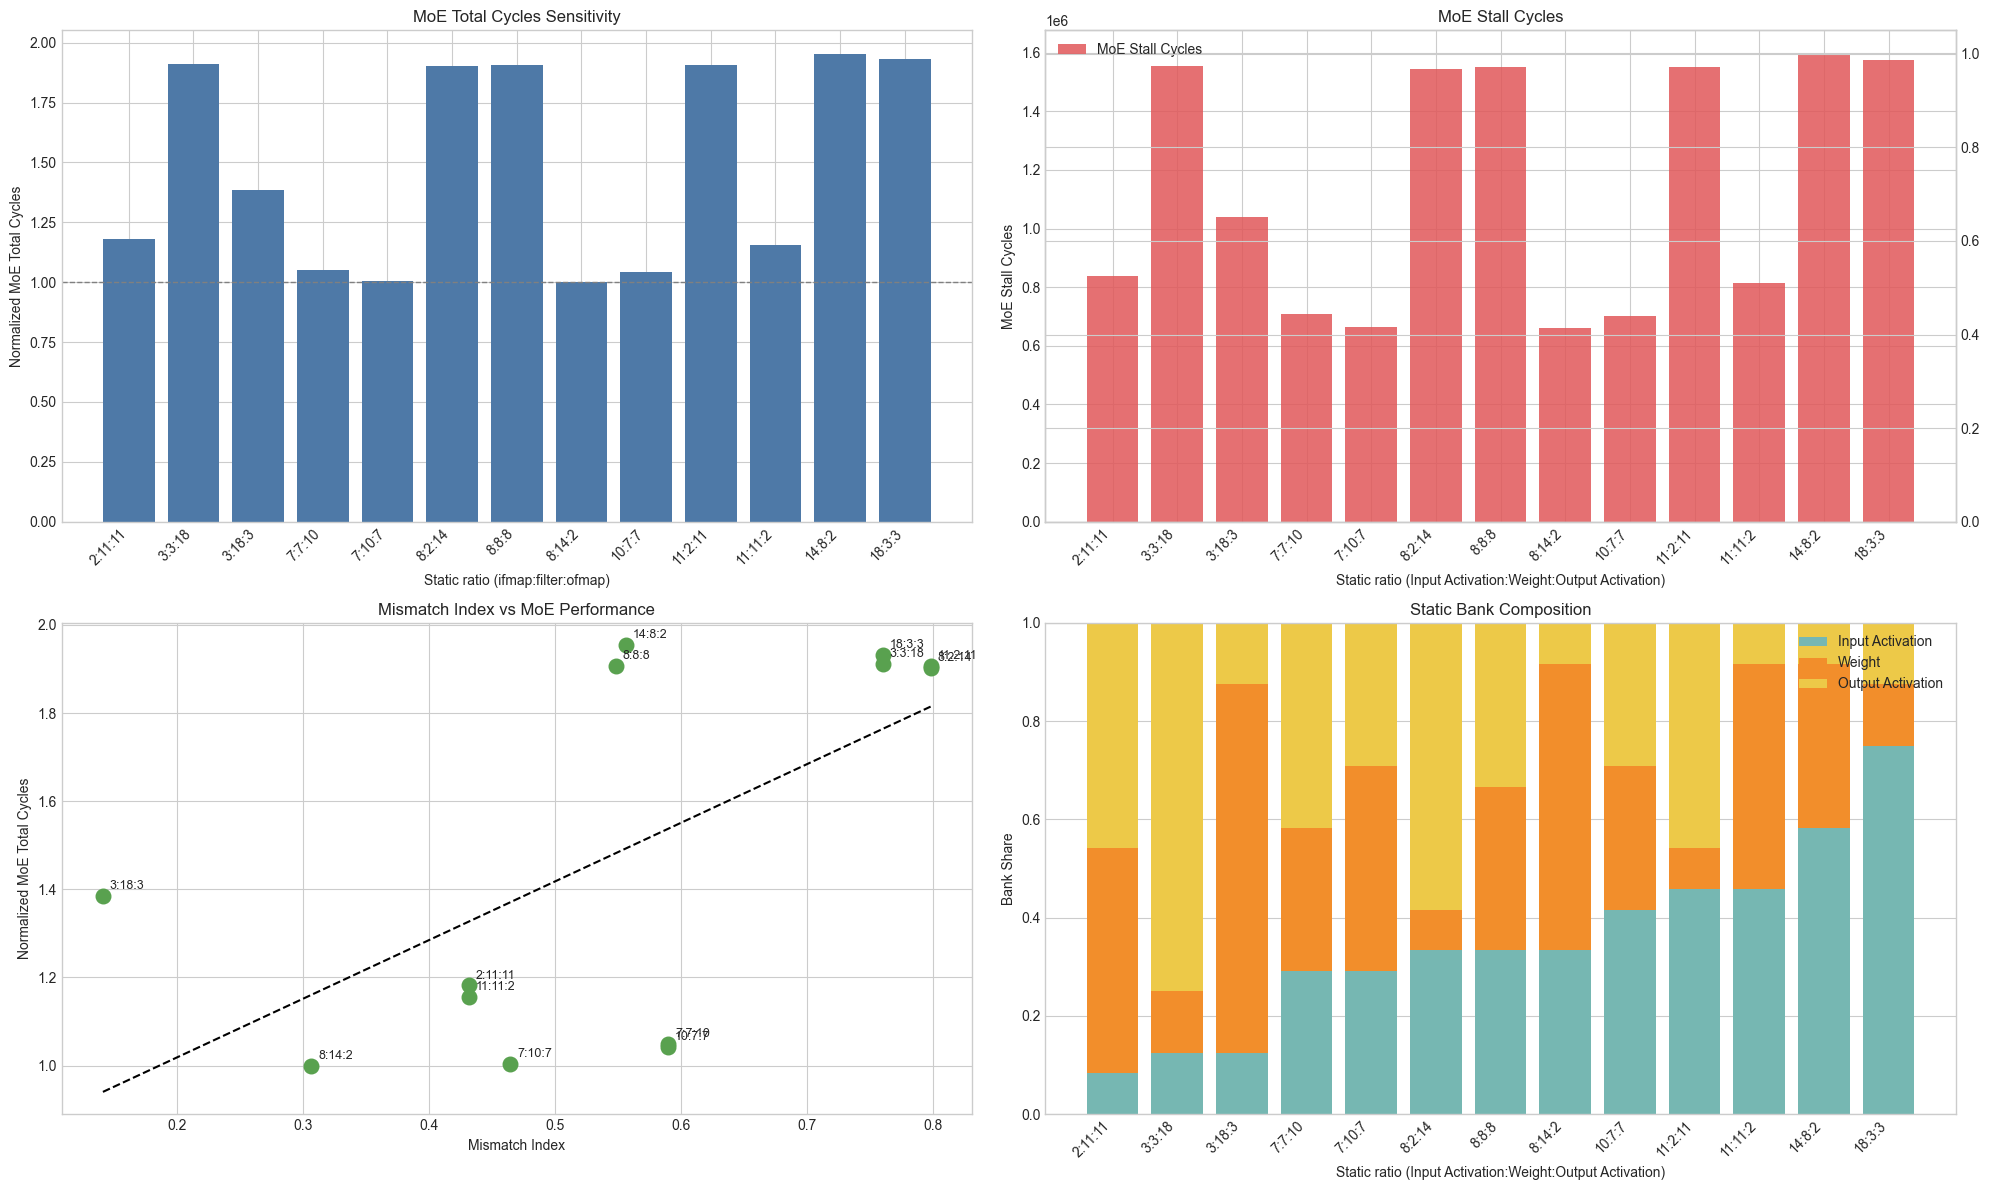

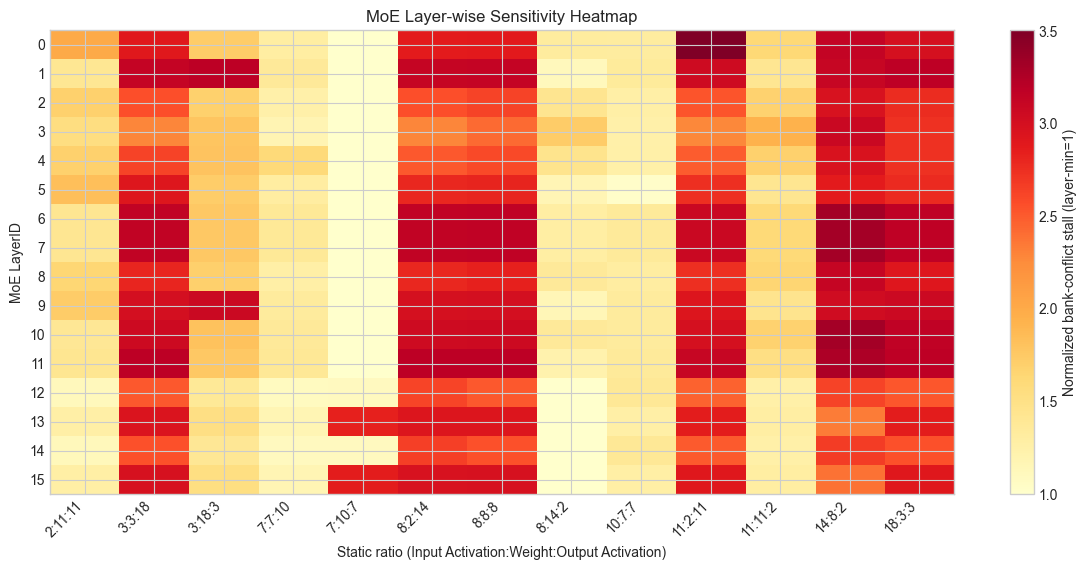

=== 结论判定 ===
归一化性能CV = 0.276
最差/最好性能比 = 1.954x
Spearman(失配指数, MoE总周期) = 0.508
Spearman(失配指数, conflict占比) = nan

实验结论: 性能对静态 bank 分配比例高度敏感，说明系统瓶颈并非来自固定计算能力不足，而主要来自静态划分下的 bank 资源失配。
由此可证明：静态分配本身是 MoE 场景下内存瓶颈的重要来源。


In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = "outputs/final4/static_exp"
run_dirs = sorted([d for d in glob.glob(f"{root}/static_*") if os.path.isdir(d)])
if not run_dirs:
    raise RuntimeError("未找到 outputs/final4/static_exp/static_* 实验目录")

records = []
layer_records = []

for run_dir in run_dirs:
    run_name = os.path.basename(run_dir)
    bank_csv = os.path.join(run_dir, "BANK_MODEL_REPORT.csv")
    comp_csv = os.path.join(run_dir, "COMPUTE_REPORT.csv")
    if not os.path.exists(bank_csv):
        continue

    bank = pd.read_csv(bank_csv)
    bank.columns = bank.columns.str.strip().str.rstrip(",")

    numeric_cols = [
        "LayerID", "ifmap_banknum", "filter_banknum", "ofmap_banknum", "total_banknum",
        "ifmap_elements", "filter_elements", "ofmap_elements",
        "ifmap_capacity_utilization", "filter_capacity_utilization", "ofmap_capacity_utilization",
        "total_bank_conflict_delay", "stall_cycles_due_to_bank_conflict", "total_cycles",
    ]
    for c in numeric_cols:
        if c in bank.columns:
            bank[c] = pd.to_numeric(bank[c], errors="coerce")

    # 当前实验报告仅包含 MoE 层，直接使用全部行
    moe = bank.copy()
    if moe.empty:
        continue

    b_if = float(moe["ifmap_banknum"].iloc[0])
    b_fi = float(moe["filter_banknum"].iloc[0])
    b_of = float(moe["ofmap_banknum"].iloc[0])
    b_tot = float(moe["total_banknum"].iloc[0])
    ratio = f"{int(b_if)}:{int(b_fi)}:{int(b_of)}"
    supply = np.array([b_if, b_fi, b_of], dtype=float) / b_tot

    mismatch_list = []
    imbalance_list = []

    for _, row in moe.iterrows():
        dem = np.array([
            row.get("ifmap_elements", np.nan),
            row.get("filter_elements", np.nan),
            row.get("ofmap_elements", np.nan),
        ], dtype=float)
        if np.isfinite(dem).all() and dem.sum() > 0:
            demand = dem / dem.sum()
            mismatch = 0.5 * np.abs(supply - demand).sum()
            mismatch_list.append(mismatch)
        else:
            mismatch = np.nan

        util = np.array([
            row.get("ifmap_capacity_utilization", np.nan),
            row.get("filter_capacity_utilization", np.nan),
            row.get("ofmap_capacity_utilization", np.nan),
        ], dtype=float)
        if np.isfinite(util).all():
            imbalance = util.max() - util.min()
            imbalance_list.append(imbalance)
        else:
            imbalance = np.nan

        layer_records.append({
            "ratio": ratio,
            "LayerID": int(row["LayerID"]),
            "bank_conflict_stall": row.get("stall_cycles_due_to_bank_conflict", np.nan),
            "mismatch": mismatch,
            "imbalance": imbalance,
        })

    moe_total_cycles = moe["total_cycles"].sum()
    moe_conflict_delay = moe["total_bank_conflict_delay"].sum()
    moe_conflict_stall = moe["stall_cycles_due_to_bank_conflict"].sum()

    moe_stall_cycles = np.nan
    moe_total_cycles_compute = np.nan
    if os.path.exists(comp_csv):
        comp = pd.read_csv(comp_csv)
        comp.columns = comp.columns.str.strip().str.rstrip(",")
        for c in ["LayerID", "Total Cycles", "Stall Cycles"]:
            if c in comp.columns:
                comp[c] = pd.to_numeric(comp[c], errors="coerce")
        if {"LayerID", "Total Cycles", "Stall Cycles"}.issubset(comp.columns):
            # 当前实验报告仅包含 MoE 层，直接使用全部行
            moe_comp = comp.copy()
            if not moe_comp.empty:
                moe_stall_cycles = moe_comp["Stall Cycles"].sum()
                moe_total_cycles_compute = moe_comp["Total Cycles"].sum()

    conflict_stall_share = np.nan
    if np.isfinite(moe_stall_cycles) and moe_stall_cycles > 0:
        conflict_stall_share = moe_conflict_stall / moe_stall_cycles

    stall_ratio = np.nan
    if np.isfinite(moe_total_cycles_compute) and moe_total_cycles_compute > 0:
        stall_ratio = moe_stall_cycles / moe_total_cycles_compute

    records.append({
        "run_name": run_name,
        "ratio": ratio,
        "ifmap_share": supply[0],
        "filter_share": supply[1],
        "ofmap_share": supply[2],
        "mismatch_index": np.nanmean(mismatch_list) if mismatch_list else np.nan,
        "avg_imbalance": np.nanmean(imbalance_list) if imbalance_list else np.nan,
        "moe_total_cycles": moe_total_cycles,
        "moe_conflict_delay": moe_conflict_delay,
        "moe_stall_cycles": moe_stall_cycles,
        "moe_stall_ratio": stall_ratio,
        "bank_conflict_stall_share": conflict_stall_share,
    })

summary = pd.DataFrame(records)
layer_df = pd.DataFrame(layer_records)
if summary.empty:
    raise RuntimeError("没有汇总到有效 MoE 数据")

ratio_parts = summary["ratio"].str.split(":", expand=True).astype(int)
summary["r_if"] = ratio_parts[0]
summary["r_fi"] = ratio_parts[1]
summary["r_of"] = ratio_parts[2]
summary = summary.sort_values(["r_if", "r_fi", "r_of"]).reset_index(drop=True)
summary["moe_total_cycles_norm"] = summary["moe_total_cycles"] / summary["moe_total_cycles"].min()

print("=== MoE静态分配敏感性汇总 ===")
display(summary[[
    "ratio", "mismatch_index", "avg_imbalance",
    "moe_total_cycles", "moe_total_cycles_norm",
    "moe_stall_cycles", "moe_stall_ratio", "bank_conflict_stall_share",
]])

x = np.arange(len(summary))
labels = summary["ratio"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

axes[0, 0].bar(x, summary["moe_total_cycles_norm"], color="#4e79a7")
axes[0, 0].set_title("MoE Total Cycles Sensitivity")
axes[0, 0].set_xlabel("Static ratio (ifmap:filter:ofmap)")
axes[0, 0].set_ylabel("Normalized MoE Total Cycles")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, rotation=45, ha="right")
axes[0, 0].axhline(1.0, linestyle="--", color="gray", linewidth=1)

axl = axes[0, 1]
axr = axl.twinx()
bars = axl.bar(x, summary["moe_stall_cycles"], color="#e15759", alpha=0.85)
# line = axr.plot(x, summary["bank_conflict_stall_share"], color="#1f77b4", marker="o", linewidth=2)[0]
axl.set_title("MoE Stall Cycles")
axl.set_xlabel("Static ratio (Input Activation:Weight:Output Activation)")
axl.set_ylabel("MoE Stall Cycles")
# axr.set_ylabel("BankConflictStallShare")
axr.set_ylim(0, 1.05)
axl.set_xticks(x)
axl.set_xticklabels(labels, rotation=45, ha="right")
axl.legend(bars, ["MoE Stall Cycles"], loc="upper left")

axes[1, 0].scatter(summary["mismatch_index"], summary["moe_total_cycles_norm"], s=110, color="#59a14f")
for _, r in summary.iterrows():
    axes[1, 0].annotate(r["ratio"], (r["mismatch_index"], r["moe_total_cycles_norm"]), xytext=(5, 5), textcoords="offset points", fontsize=9)

valid = summary[["mismatch_index", "moe_total_cycles_norm"]].dropna()
if len(valid) >= 2:
    k, b = np.polyfit(valid["mismatch_index"], valid["moe_total_cycles_norm"], 1)
    xx = np.linspace(valid["mismatch_index"].min(), valid["mismatch_index"].max(), 100)
    axes[1, 0].plot(xx, k * xx + b, linestyle="--", color="black", linewidth=1.5)

axes[1, 0].set_title("Mismatch Index vs MoE Performance")
axes[1, 0].set_xlabel("Mismatch Index")
axes[1, 0].set_ylabel("Normalized MoE Total Cycles")

axes[1, 1].bar(x, summary["ifmap_share"], label="Input Activation", color="#76b7b2")
axes[1, 1].bar(x, summary["filter_share"], bottom=summary["ifmap_share"], label="Weight", color="#f28e2b")
bottom2 = summary["ifmap_share"] + summary["filter_share"]
axes[1, 1].bar(x, summary["ofmap_share"], bottom=bottom2, label="Output Activation", color="#edc948")
axes[1, 1].set_title("Static Bank Composition")
axes[1, 1].set_xlabel("Static ratio (Input Activation:Weight:Output Activation)")
axes[1, 1].set_ylabel("Bank Share")
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels, rotation=45, ha="right")
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

if not layer_df.empty:
    pivot = layer_df.pivot_table(index="LayerID", columns="ratio", values="bank_conflict_stall", aggfunc="mean")
    pivot = pivot.reindex(columns=summary["ratio"].tolist()).sort_index()
    pivot_norm = pivot.div(pivot.min(axis=1), axis=0)

    plt.figure(figsize=(max(12, len(pivot_norm.columns) * 0.9), 5.8))
    im = plt.imshow(pivot_norm.values, aspect="auto", cmap="YlOrRd")
    plt.colorbar(im, label="Normalized bank-conflict stall (layer-min=1)")
    plt.xticks(np.arange(len(pivot_norm.columns)), pivot_norm.columns, rotation=45, ha="right")
    plt.yticks(np.arange(len(pivot_norm.index)), pivot_norm.index)
    plt.xlabel("Static ratio (Input Activation:Weight:Output Activation)")
    plt.ylabel("MoE LayerID")
    plt.title("MoE Layer-wise Sensitivity Heatmap")
    plt.tight_layout()
    plt.show()

perf = summary["moe_total_cycles_norm"].dropna()
cv = perf.std(ddof=0) / perf.mean() if len(perf) > 1 else np.nan
worst_best = perf.max() / perf.min() if len(perf) > 0 else np.nan
corr_perf = summary[["mismatch_index", "moe_total_cycles_norm"]].corr(method="spearman").iloc[0, 1]
corr_conflict = summary[["mismatch_index", "bank_conflict_stall_share"]].corr(method="spearman").iloc[0, 1]

print("=== 结论判定 ===")
print(f"归一化性能CV = {cv:.3f}")
print(f"最差/最好性能比 = {worst_best:.3f}x")
print(f"Spearman(失配指数, MoE总周期) = {corr_perf:.3f}")
print(f"Spearman(失配指数, conflict占比) = {corr_conflict:.3f}")

high_sensitivity = (cv > 0.12) or (worst_best > 1.20)
mismatch_linked = (corr_perf > 0.40)
if high_sensitivity and mismatch_linked:
    print("\n实验结论: 性能对静态 bank 分配比例高度敏感，说明系统瓶颈并非来自固定计算能力不足，而主要来自静态划分下的 bank 资源失配。")
    print("由此可证明：静态分配本身是 MoE 场景下内存瓶颈的重要来源。")
else:
    print("\n实验结论: 当前数据对假设提供部分支持，但建议进一步扩展比例与负载做更强验证。")

=== 三文件对比（MoE层, 固定16层）===


,run,MoE_RowCount,MoE_TotalCycles,MoE_StallCycles,MoE_ConflictDelay,Unique_MoE_Ratios
0,Static_8:8:8,16,1870007.0,1549983.0,37212777.0,1
1,Dynamic_24,16,781811.0,461787.0,10353438.0,8
2,Static_7:10:7,16,984665.0,664641.0,13708146.0,1


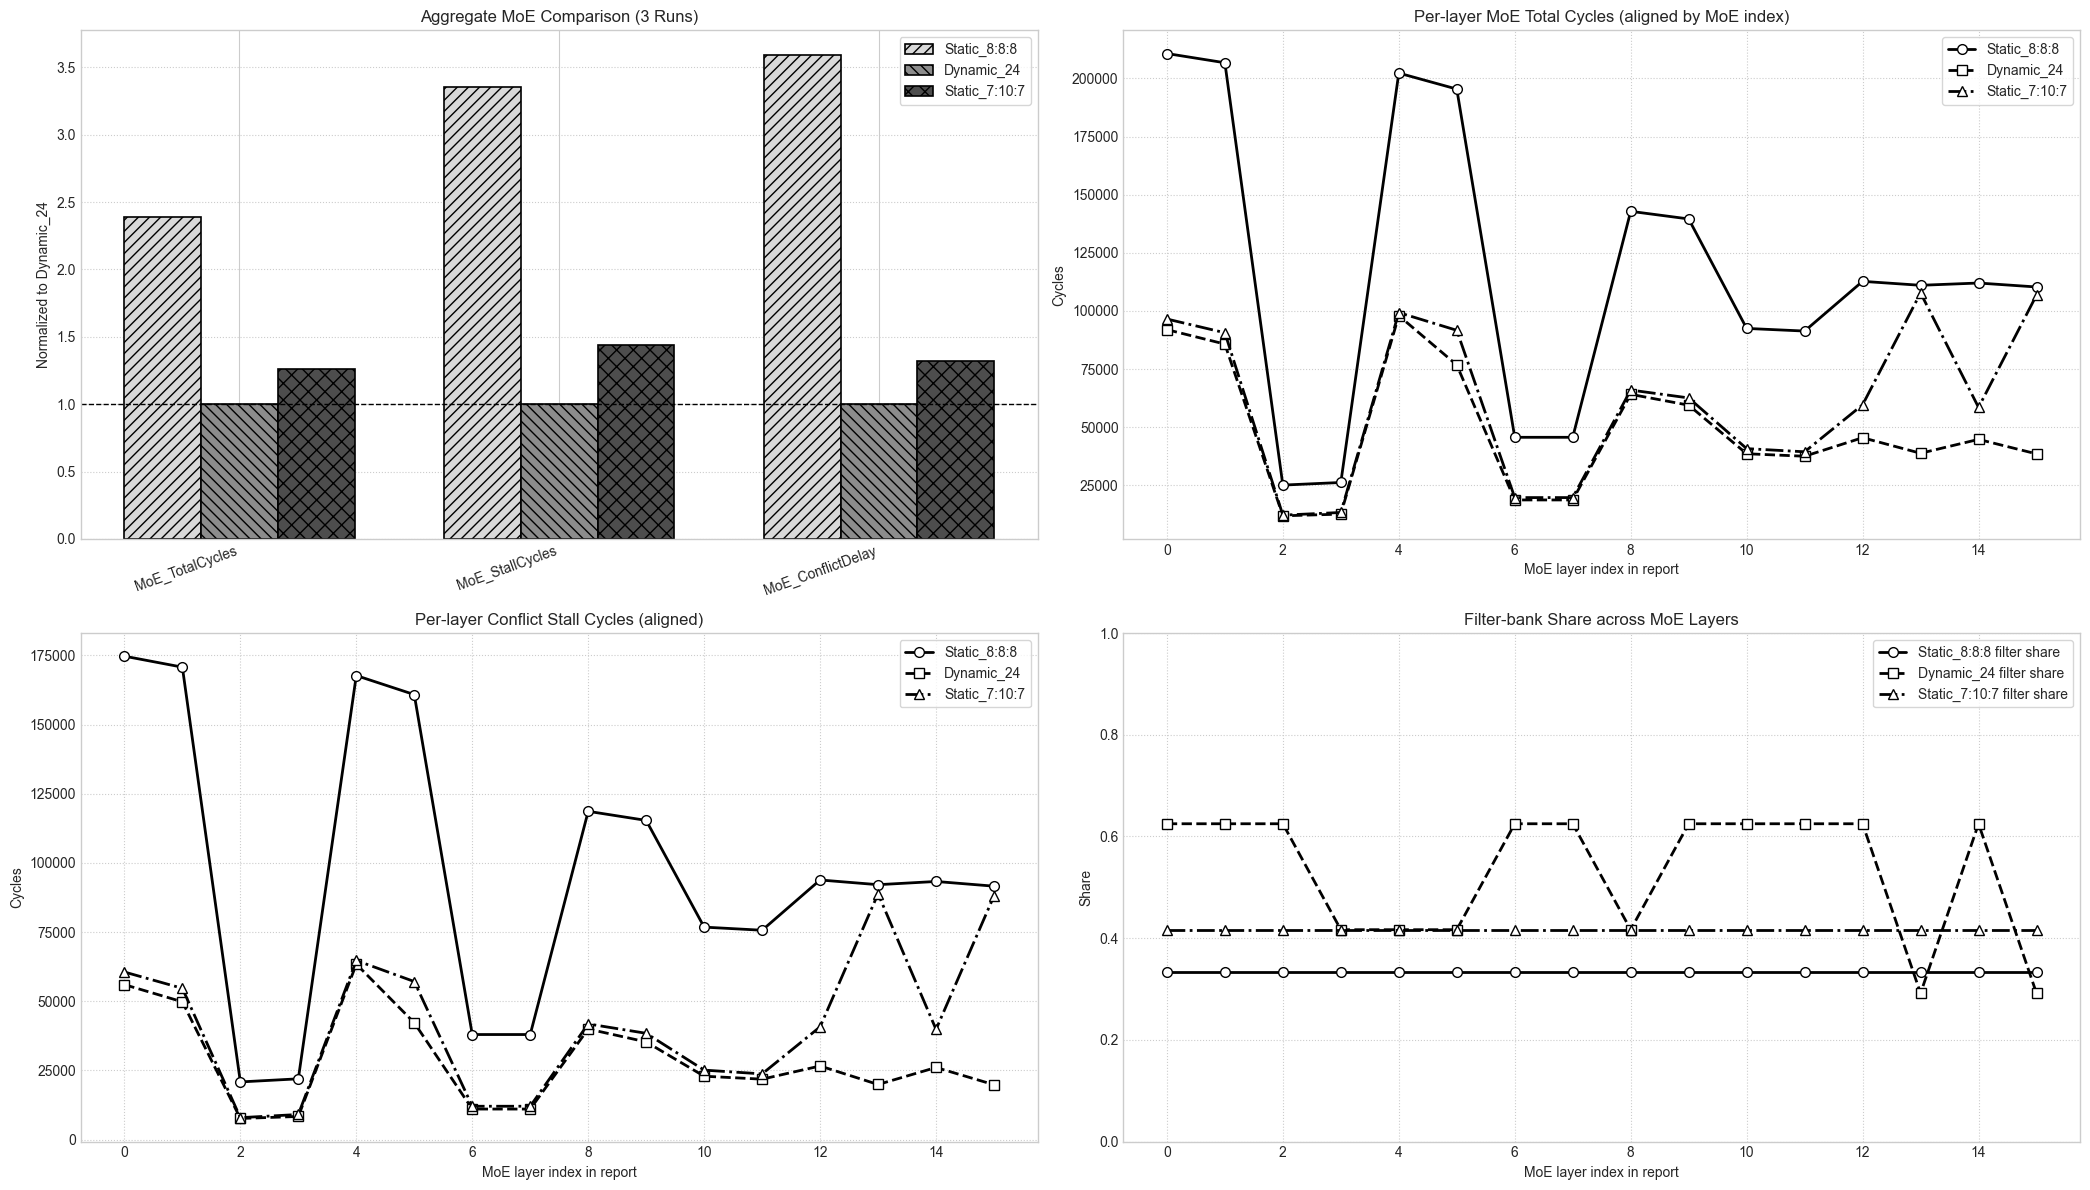

Dynamic_24 vs Static_8:8:8: Total 58.19%, Stall 70.21%, ConflictDelay 72.18%
Dynamic_24 vs Static_7:10:7: Total 20.60%, Stall 30.52%, ConflictDelay 24.47%


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIRS = {
    "Static_8:8:8": "/home/MikeNotFound/code/SCALE-Sim/outputs/final4/static_8_8_8",
    "Dynamic_24": "/home/MikeNotFound/code/SCALE-Sim/outputs/final4/dynamic_24",
    "Static_7:10:7": "/home/MikeNotFound/code/SCALE-Sim/outputs/final4/static_exp/static_7_10_7",
}

BASE_RUN = "Dynamic_24"
EXPECTED_MOE_LAYERS = 16
FULL_MODEL_MOE_MIN, FULL_MODEL_MOE_MAX = 7, 22  # 8 experts x (FF1, FF2)


def _extract_moe_rows(df: pd.DataFrame, layer_col: str = "LayerID") -> pd.DataFrame:
    if layer_col not in df.columns:
        raise RuntimeError("报告缺少 LayerID 列，无法提取 16 层 MoE")

    src = df.copy()
    src[layer_col] = pd.to_numeric(src[layer_col], errors="coerce")
    src = src.dropna(subset=[layer_col]).copy()
    src[layer_col] = src[layer_col].astype(int)
    ids = sorted(src[layer_col].unique().tolist())

    # Case A: full-network report, MoE is LayerID 7..22
    in_full_moe = src[
        (src[layer_col] >= FULL_MODEL_MOE_MIN)
        & (src[layer_col] <= FULL_MODEL_MOE_MAX)
    ].copy()

    if len(in_full_moe) == EXPECTED_MOE_LAYERS:
        target = in_full_moe
    else:
        # Case B: MoE-only report already remapped to 0..15
        if (
            len(ids) == EXPECTED_MOE_LAYERS
            and ids[0] == 0
            and ids[-1] == EXPECTED_MOE_LAYERS - 1
        ):
            target = src.copy()
        else:
            raise RuntimeError(
                f"无法提取 16 层 MoE：LayerID 分布={ids[:6]}..."
                f"{ids[-6:] if len(ids) > 6 else ids}，总行数={len(src)}"
            )

    target = target.sort_values(layer_col).reset_index(drop=True)
    target["MoE_Idx"] = np.arange(len(target), dtype=int)
    return target


def _load_moe(run_name: str, run_dir: str):
    bank_csv = os.path.join(run_dir, "BANK_MODEL_REPORT.csv")
    comp_csv = os.path.join(run_dir, "COMPUTE_REPORT.csv")

    if not os.path.exists(bank_csv):
        raise FileNotFoundError(f"缺少文件: {bank_csv}")

    bank = pd.read_csv(bank_csv)
    bank.columns = bank.columns.str.strip().str.rstrip(",")

    for c in [
        "LayerID",
        "total_cycles",
        "stall_cycles_due_to_bank_conflict",
        "total_bank_conflict_delay",
        "ifmap_banknum",
        "filter_banknum",
        "ofmap_banknum",
        "total_banknum",
    ]:
        if c in bank.columns:
            bank[c] = pd.to_numeric(bank[c], errors="coerce")

    moe = _extract_moe_rows(bank, layer_col="LayerID")

    moe_stall = np.nan
    if os.path.exists(comp_csv):
        comp = pd.read_csv(comp_csv)
        comp.columns = comp.columns.str.strip().str.rstrip(",")

        for c in ["LayerID", "Stall Cycles"]:
            if c in comp.columns:
                comp[c] = pd.to_numeric(comp[c], errors="coerce")

        if "Stall Cycles" in comp.columns and "LayerID" in comp.columns:
            moe_comp = _extract_moe_rows(
                comp[["LayerID", "Stall Cycles"]].copy(),
                layer_col="LayerID",
            )
            if not moe_comp.empty:
                moe_stall = moe_comp["Stall Cycles"].sum()

    ratio_parts = moe["allocation_ratio"].astype(str).str.split(":", expand=True).astype(float)
    ratio_parts.columns = ["ifmap_b", "filter_b", "ofmap_b"]
    ratio_parts["total_b"] = ratio_parts.sum(axis=1)
    ratio_parts["ifmap_s"] = ratio_parts["ifmap_b"] / ratio_parts["total_b"]
    ratio_parts["filter_s"] = ratio_parts["filter_b"] / ratio_parts["total_b"]
    ratio_parts["ofmap_s"] = ratio_parts["ofmap_b"] / ratio_parts["total_b"]
    ratio_parts["MoE_Idx"] = moe["MoE_Idx"].values

    summary = {
        "run": run_name,
        "MoE_RowCount": int(len(moe)),
        "MoE_TotalCycles": float(moe["total_cycles"].sum()),
        "MoE_StallCycles": float(moe_stall) if np.isfinite(moe_stall) else np.nan,
        "MoE_ConflictDelay": float(moe["total_bank_conflict_delay"].sum()),
        "Unique_MoE_Ratios": int(moe["allocation_ratio"].astype(str).nunique())
        if "allocation_ratio" in moe.columns
        else np.nan,
    }

    return summary, moe, ratio_parts


records, moe_map, ratio_map = [], {}, {}

for run_name, run_dir in RUN_DIRS.items():
    rec, moe_df, ratio_df = _load_moe(run_name, run_dir)
    records.append(rec)
    moe_map[run_name] = moe_df
    ratio_map[run_name] = ratio_df

runs = list(RUN_DIRS.keys())

summary3 = pd.DataFrame(records)
print("=== 三文件对比（MoE层, 固定16层）===")
display(summary3)

if BASE_RUN not in summary3["run"].values:
    raise RuntimeError(f"未找到基线: {BASE_RUN}")

metric_cols = ["MoE_TotalCycles", "MoE_StallCycles", "MoE_ConflictDelay"]

norm = summary3.set_index("run")[metric_cols].div(
    summary3.set_index("run").loc[BASE_RUN, metric_cols],
    axis=1,
)

layer_cmp = None

for run in runs:
    cur = moe_map[run][
        [
            "MoE_Idx",
            "LayerID",
            "total_cycles",
            "stall_cycles_due_to_bank_conflict",
        ]
    ].copy()

    cur = cur.rename(
        columns={
            "LayerID": f"{run}_raw_layerid",
            "total_cycles": f"{run}_total",
            "stall_cycles_due_to_bank_conflict": f"{run}_conflict_stall",
        }
    )

    layer_cmp = cur if layer_cmp is None else layer_cmp.merge(
        cur,
        on="MoE_Idx",
        how="inner",
    )

if layer_cmp is None or layer_cmp.empty or len(layer_cmp) != EXPECTED_MOE_LAYERS:
    raise RuntimeError("三组数据在 MoE 层对齐失败，未得到 16 层公共数据")


# ============================================================
# 黑白打印友好绘图设置
# 不再使用颜色区分，而是使用：
# 1. 柱状图：灰度 + hatch 填充纹理
# 2. 折线图：线型 + marker 点型
# ============================================================

style_map = {
    "Static_8:8:8": {
        "linestyle": "-",
        "marker": "o",
        "hatch": "///",
        "gray": "0.85",
    },
    "Dynamic_24": {
        "linestyle": "--",
        "marker": "s",
        "hatch": "\\\\\\",
        "gray": "0.55",
    },
    "Static_7:10:7": {
        "linestyle": "-.",
        "marker": "^",
        "hatch": "xx",
        "gray": "0.30",
    },
}


fig, axes = plt.subplots(2, 2, figsize=(21, 12))

x = np.arange(len(metric_cols))
w = 0.24


# ------------------------------------------------------------
# 子图 1：三种策略的整体指标对比
# 使用灰度 + hatch 纹理，适合黑白打印
# ------------------------------------------------------------

for i, run in enumerate(runs):
    st = style_map[run]

    axes[0, 0].bar(
        x + (i - 1) * w,
        norm.loc[run, metric_cols].values,
        width=w,
        label=run,
        color=st["gray"],
        edgecolor="black",
        linewidth=1.2,
        hatch=st["hatch"],
    )

axes[0, 0].axhline(
    1.0,
    linestyle="--",
    color="black",
    linewidth=1,
)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(
    metric_cols,
    rotation=20,
    ha="right",
)

axes[0, 0].set_ylabel(f"Normalized to {BASE_RUN}")
axes[0, 0].set_title("Aggregate MoE Comparison (3 Runs)")
axes[0, 0].legend(loc="best", frameon=True)
axes[0, 0].grid(axis="y", linestyle=":", linewidth=0.8)


# ------------------------------------------------------------
# 子图 2：逐 MoE 层 total cycles 对比
# 使用线型 + marker 区分不同策略
# ------------------------------------------------------------

for run in runs:
    st = style_map[run]

    axes[0, 1].plot(
        layer_cmp["MoE_Idx"],
        layer_cmp[f"{run}_total"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        linewidth=2,
        markersize=7,
        label=run,
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
    )

axes[0, 1].set_title("Per-layer MoE Total Cycles (aligned by MoE index)")
axes[0, 1].set_xlabel("MoE layer index in report")
axes[0, 1].set_ylabel("Cycles")
axes[0, 1].legend(loc="best", frameon=True)
axes[0, 1].grid(True, linestyle=":", linewidth=0.8)


# ------------------------------------------------------------
# 子图 3：逐 MoE 层 bank conflict stall 对比
# 使用线型 + marker 区分不同策略
# ------------------------------------------------------------

for run in runs:
    st = style_map[run]

    axes[1, 0].plot(
        layer_cmp["MoE_Idx"],
        layer_cmp[f"{run}_conflict_stall"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        linewidth=2,
        markersize=7,
        label=run,
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
    )

axes[1, 0].set_title("Per-layer Conflict Stall Cycles (aligned)")
axes[1, 0].set_xlabel("MoE layer index in report")
axes[1, 0].set_ylabel("Cycles")
axes[1, 0].legend(loc="best", frameon=True)
axes[1, 0].grid(True, linestyle=":", linewidth=0.8)


# ------------------------------------------------------------
# 子图 4：逐 MoE 层 filter-bank share 对比
# 使用线型 + marker 区分不同策略
# ------------------------------------------------------------

for run in runs:
    st = style_map[run]
    r = ratio_map[run].sort_values("MoE_Idx")

    axes[1, 1].plot(
        r["MoE_Idx"],
        r["filter_s"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        linewidth=2,
        markersize=7,
        label=f"{run} filter share",
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
    )

axes[1, 1].set_title("Filter-bank Share across MoE Layers")
axes[1, 1].set_xlabel("MoE layer index in report")
axes[1, 1].set_ylabel("Share")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc="best", frameon=True)
axes[1, 1].grid(True, linestyle=":", linewidth=0.8)


plt.tight_layout()
plt.show()


# ============================================================
# 打印 Dynamic_24 相比两个静态策略的改善比例
# ============================================================

row = summary3.set_index("run")

for s in ["Static_8:8:8", "Static_7:10:7"]:
    imp_total = (
        row.loc[s, "MoE_TotalCycles"] - row.loc[BASE_RUN, "MoE_TotalCycles"]
    ) / row.loc[s, "MoE_TotalCycles"]

    imp_stall = (
        row.loc[s, "MoE_StallCycles"] - row.loc[BASE_RUN, "MoE_StallCycles"]
    ) / row.loc[s, "MoE_StallCycles"]

    imp_conf = (
        row.loc[s, "MoE_ConflictDelay"] - row.loc[BASE_RUN, "MoE_ConflictDelay"]
    ) / row.loc[s, "MoE_ConflictDelay"]

    print(
        f"{BASE_RUN} vs {s}: "
        f"Total {imp_total:.2%}, "
        f"Stall {imp_stall:.2%}, "
        f"ConflictDelay {imp_conf:.2%}"
    )

=== MoE层：三种策略跨 banknum 对比汇总 ===


,Strategy,TotalBankNum,MoE_TotalCycles,MoE_ConflictStall,MoE_ConflictDelay,RowCount,AllocRatio_mode,AllocRatio_n
0,Dynamic Virtualization,6,7844383.0,7700391.0,209628102.0,8,2:2:2,3
1,Static Better-Allocated,6,8931574.0,8787582.0,232091508.0,8,1:2:3,1
2,Static Uniform,6,7942513.0,7798521.0,213398526.0,8,2:2:2,1
3,Dynamic Virtualization,12,1980232.0,1210704.0,9509424.0,8,2:6:4,6
4,Static Better-Allocated,12,3107776.0,2963784.0,112503666.0,8,3:5:4,1
5,Static Uniform,12,6086434.0,5942442.0,168570264.0,8,4:4:4,1
6,Dynamic Virtualization,24,347548.0,203556.0,4280673.0,8,2:15:7,5
7,Static Better-Allocated,24,454468.0,310476.0,6045603.0,8,7:10:7,1
8,Static Uniform,24,4710562.0,4566570.0,132448788.0,8,8:8:8,1
9,Dynamic Virtualization,48,466087.0,322095.0,10059384.0,8,7:30:11,7


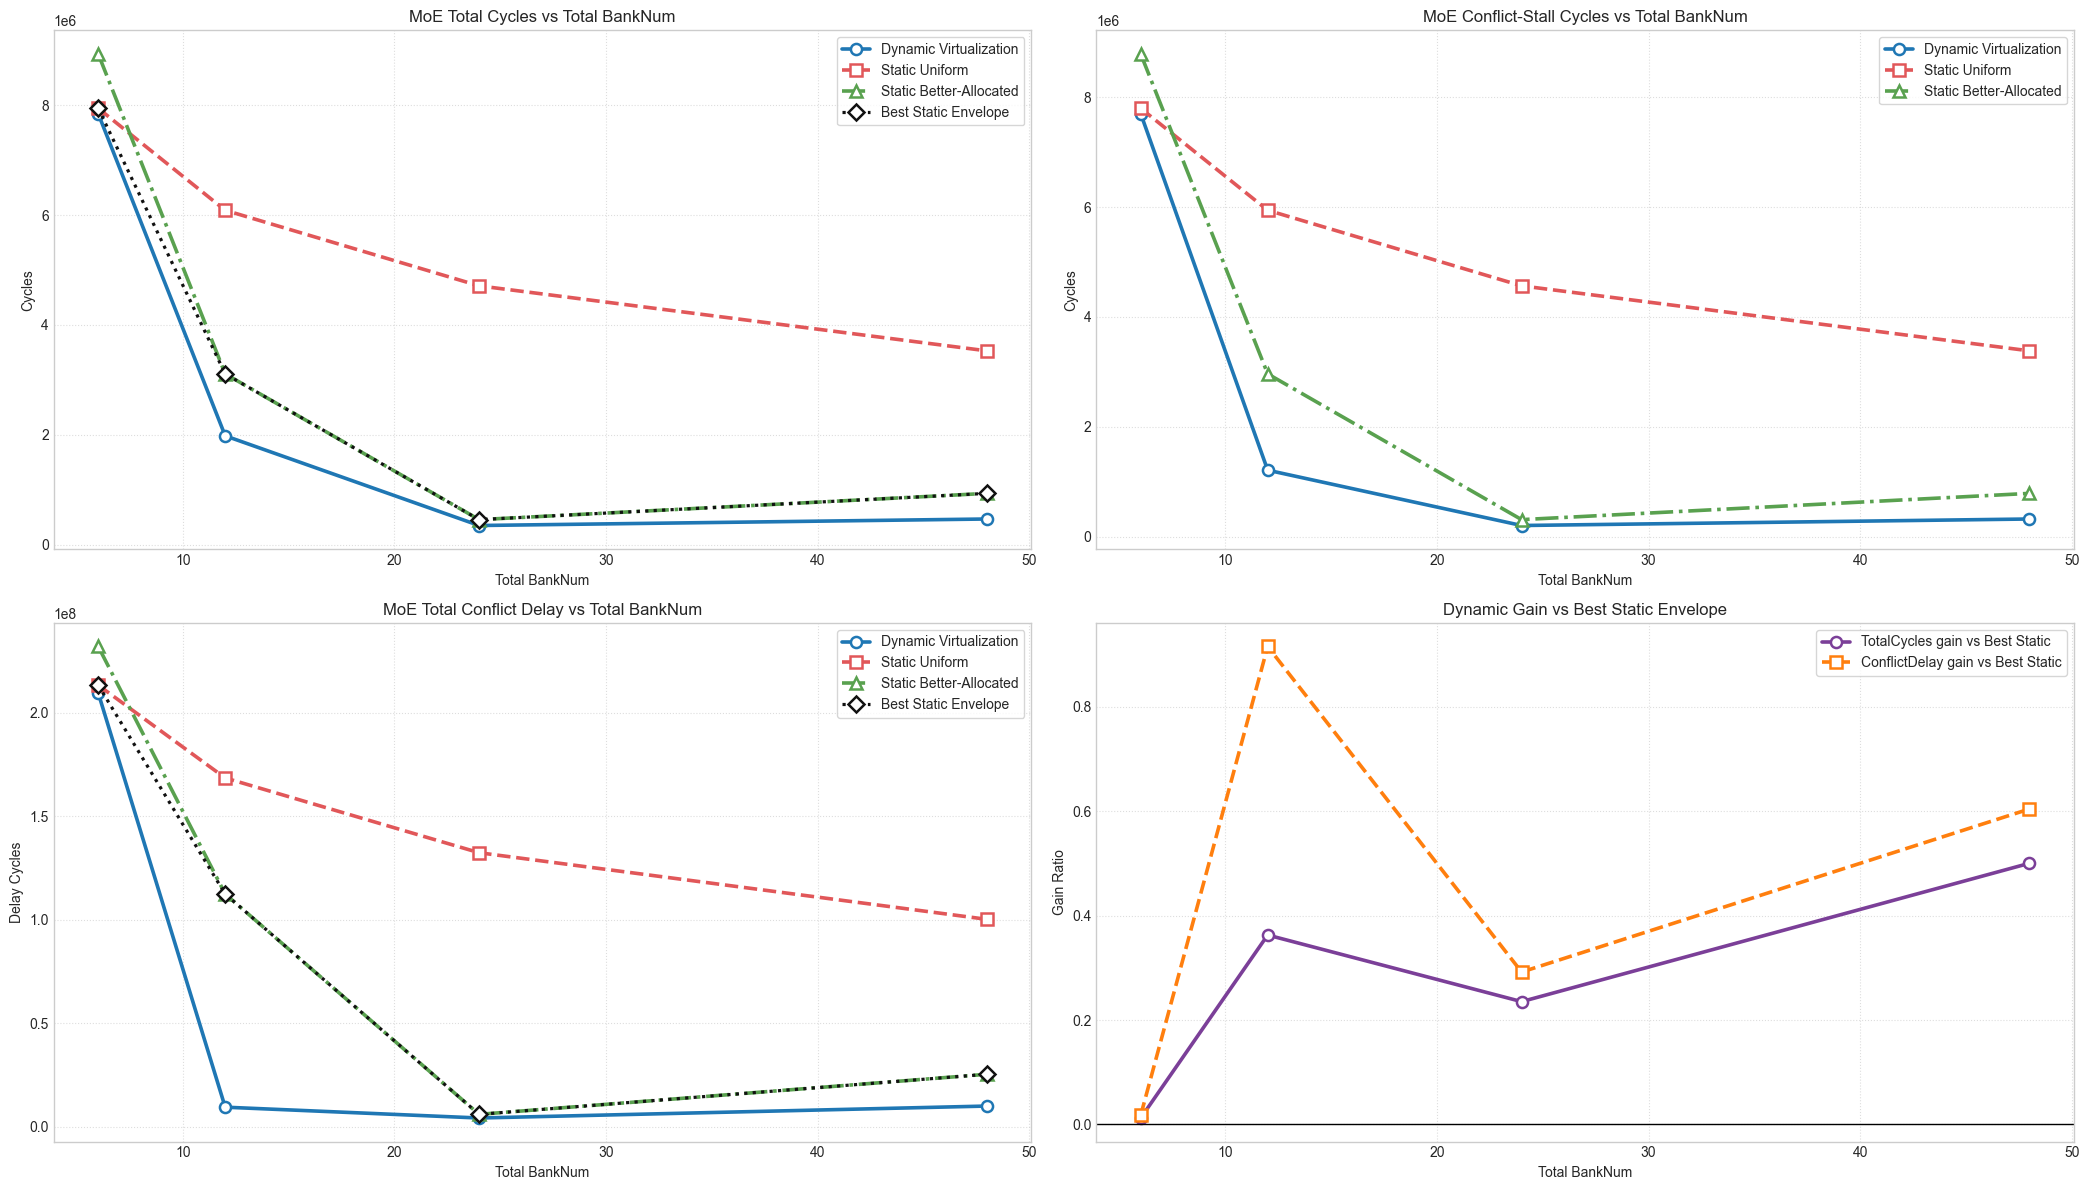


=== 实验结论（稳定性视角）===
动态相对‘同banknum最优静态’在 TotalCycles 上是否全点非劣: True
动态相对‘同banknum最优静态’在 ConflictDelay 上是否全点非劣: True
动态在 TotalCycles 上严格优于最优静态的点数: 4/4
动态在 ConflictDelay 上严格优于最优静态的点数: 4/4
低bank(6/12) 相对最优静态平均 TotalCycles 收益: 18.76%
高bank(24/48) 相对最优静态平均 TotalCycles 收益: 36.78%
低bank(6/12) 相对最优静态平均 ConflictDelay 收益: 46.66%
高bank(24/48) 相对最优静态平均 ConflictDelay 收益: 44.81%
结论: 动态虚拟化在不同资源压力下表现出稳定的适应能力。
在 MoE 非均衡访存与高并发计算场景中，动态策略能够持续抑制 bank 冲突并降低总体延时。


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "outputs/final4"

RUNS = {
    "Dynamic Virtualization": {
        6: os.path.join(ROOT, "banknum_exp", "dynamic_banknum6"),
        12: os.path.join(ROOT, "banknum_exp", "dynamic_banknum12"),
        24: os.path.join(ROOT, "dynamic_24"),
        48: os.path.join(ROOT, "banknum_exp", "dynamic_banknum48"),
    },
    "Static Uniform": {
        6: os.path.join(ROOT, "banknum_exp", "static_banknum6_2_2_2"),
        12: os.path.join(ROOT, "banknum_exp", "static_banknum12_4_4_4"),
        24: os.path.join(ROOT, "banknum_exp", "static_banknum24_8_8_8"),
        48: os.path.join(ROOT, "banknum_exp", "static_banknum48_16_16_16"),
    },
    "Static Better-Allocated": {
        6: os.path.join(ROOT, "banknum_exp", "static_banknum6_1_2_3"),
        12: os.path.join(ROOT, "banknum_exp", "static_banknum12_3_5_4"),
        24: os.path.join(ROOT, "static_exp", "static_7_10_7"),
        48: os.path.join(ROOT, "banknum_exp", "static_banknum48_14_20_14"),
    },
}


def _load_moe_metrics(run_dir: str):
    bank_csv = os.path.join(run_dir, "BANK_MODEL_REPORT.csv")

    if not os.path.exists(bank_csv):
        raise FileNotFoundError(f"Missing: {bank_csv}")

    bank = pd.read_csv(bank_csv)
    bank.columns = bank.columns.str.strip().str.rstrip(",")

    for c in [
        "LayerID",
        "total_cycles",
        "stall_cycles_due_to_bank_conflict",
        "total_bank_conflict_delay",
        "total_banknum",
    ]:
        if c in bank.columns:
            bank[c] = pd.to_numeric(bank[c], errors="coerce")

    if "LayerID" in bank.columns and bank["LayerID"].max() >= 14:
        moe = bank[(bank["LayerID"] >= 7) & (bank["LayerID"] <= 14)].copy()
        if moe.empty:
            moe = bank.copy()
    else:
        moe = bank.copy()

    ratio_mode = (
        moe["allocation_ratio"].astype(str).mode().iloc[0]
        if "allocation_ratio" in moe.columns
        else "NA"
    )

    ratio_n = (
        moe["allocation_ratio"].astype(str).nunique()
        if "allocation_ratio" in moe.columns
        else np.nan
    )

    return {
        "MoE_TotalCycles": float(moe["total_cycles"].sum()),
        "MoE_ConflictStall": float(moe["stall_cycles_due_to_bank_conflict"].sum()),
        "MoE_ConflictDelay": float(moe["total_bank_conflict_delay"].sum()),
        "RowCount": int(len(moe)),
        "AllocRatio_mode": ratio_mode,
        "AllocRatio_n": int(ratio_n) if np.isfinite(ratio_n) else np.nan,
    }


records = []

for strategy, bm in RUNS.items():
    for banknum, run_dir in bm.items():
        m = _load_moe_metrics(run_dir)
        records.append(
            {
                "Strategy": strategy,
                "TotalBankNum": int(banknum),
                "RunDir": run_dir,
                **m,
            }
        )

res = (
    pd.DataFrame(records)
    .sort_values(["TotalBankNum", "Strategy"])
    .reset_index(drop=True)
)

print("=== MoE层：三种策略跨 banknum 对比汇总 ===")
display(
    res[
        [
            "Strategy",
            "TotalBankNum",
            "MoE_TotalCycles",
            "MoE_ConflictStall",
            "MoE_ConflictDelay",
            "RowCount",
            "AllocRatio_mode",
            "AllocRatio_n",
        ]
    ]
)

pivot_total = (
    res.pivot(index="TotalBankNum", columns="Strategy", values="MoE_TotalCycles")
    .sort_index()
)

pivot_stall = (
    res.pivot(index="TotalBankNum", columns="Strategy", values="MoE_ConflictStall")
    .sort_index()
)

pivot_delay = (
    res.pivot(index="TotalBankNum", columns="Strategy", values="MoE_ConflictDelay")
    .sort_index()
)

best_static_total = pd.concat(
    [
        pivot_total["Static Uniform"],
        pivot_total["Static Better-Allocated"],
    ],
    axis=1,
).min(axis=1)

best_static_delay = pd.concat(
    [
        pivot_delay["Static Uniform"],
        pivot_delay["Static Better-Allocated"],
    ],
    axis=1,
).min(axis=1)

imp = pd.DataFrame(index=pivot_total.index)

for base in ["Static Uniform", "Static Better-Allocated"]:
    imp[f"Dyn_vs_{base}_TotalCycles"] = (
        pivot_total[base] - pivot_total["Dynamic Virtualization"]
    ) / pivot_total[base]

    imp[f"Dyn_vs_{base}_ConflictDelay"] = (
        pivot_delay[base] - pivot_delay["Dynamic Virtualization"]
    ) / pivot_delay[base]

imp["Dyn_vs_BestStatic_TotalCycles"] = (
    best_static_total - pivot_total["Dynamic Virtualization"]
) / best_static_total

imp["Dyn_vs_BestStatic_ConflictDelay"] = (
    best_static_delay - pivot_delay["Dynamic Virtualization"]
) / best_static_delay


# ============================================================
# 彩色 + 黑白打印友好的绘图样式
# 彩色打印：通过 color 区分
# 黑白打印：通过 linestyle + marker 区分
# ============================================================

style_map = {
    "Dynamic Virtualization": {
        "color": "#1f77b4",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "white",
        "label": "Dynamic Virtualization",
    },
    "Static Uniform": {
        "color": "#e15759",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
        "label": "Static Uniform",
    },
    "Static Better-Allocated": {
        "color": "#59a14f",
        "linestyle": "-.",
        "marker": "^",
        "markerfacecolor": "white",
        "label": "Static Better-Allocated",
    },
}

best_static_style = {
    "color": "#111111",
    "linestyle": ":",
    "marker": "D",
    "markerfacecolor": "white",
    "label": "Best Static Envelope",
}

gain_style_map = {
    "TotalCycles gain vs Best Static": {
        "color": "#7b3f98",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "white",
    },
    "ConflictDelay gain vs Best Static": {
        "color": "#ff7f0e",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
    },
}


fig, axes = plt.subplots(2, 2, figsize=(21, 12))


# ------------------------------------------------------------
# 子图 1：MoE Total Cycles vs Total BankNum
# ------------------------------------------------------------

for s in ["Dynamic Virtualization", "Static Uniform", "Static Better-Allocated"]:
    st = style_map[s]

    axes[0, 0].plot(
        pivot_total.index,
        pivot_total[s],
        color=st["color"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.8,
        linewidth=2.6,
        markersize=8,
        label=st["label"],
    )

axes[0, 0].plot(
    best_static_total.index,
    best_static_total.values,
    color=best_static_style["color"],
    linestyle=best_static_style["linestyle"],
    marker=best_static_style["marker"],
    markerfacecolor=best_static_style["markerfacecolor"],
    markeredgecolor=best_static_style["color"],
    markeredgewidth=1.8,
    linewidth=2.3,
    markersize=8,
    label=best_static_style["label"],
)

axes[0, 0].set_title("MoE Total Cycles vs Total BankNum")
axes[0, 0].set_xlabel("Total BankNum")
axes[0, 0].set_ylabel("Cycles")
axes[0, 0].legend(loc="best", frameon=True)
axes[0, 0].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)


# ------------------------------------------------------------
# 子图 2：MoE Conflict-Stall Cycles vs Total BankNum
# ------------------------------------------------------------

for s in ["Dynamic Virtualization", "Static Uniform", "Static Better-Allocated"]:
    st = style_map[s]

    axes[0, 1].plot(
        pivot_stall.index,
        pivot_stall[s],
        color=st["color"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.8,
        linewidth=2.6,
        markersize=8,
        label=st["label"],
    )

axes[0, 1].set_title("MoE Conflict-Stall Cycles vs Total BankNum")
axes[0, 1].set_xlabel("Total BankNum")
axes[0, 1].set_ylabel("Cycles")
axes[0, 1].legend(loc="best", frameon=True)
axes[0, 1].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)


# ------------------------------------------------------------
# 子图 3：MoE Total Conflict Delay vs Total BankNum
# ------------------------------------------------------------

for s in ["Dynamic Virtualization", "Static Uniform", "Static Better-Allocated"]:
    st = style_map[s]

    axes[1, 0].plot(
        pivot_delay.index,
        pivot_delay[s],
        color=st["color"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.8,
        linewidth=2.6,
        markersize=8,
        label=st["label"],
    )

axes[1, 0].plot(
    best_static_delay.index,
    best_static_delay.values,
    color=best_static_style["color"],
    linestyle=best_static_style["linestyle"],
    marker=best_static_style["marker"],
    markerfacecolor=best_static_style["markerfacecolor"],
    markeredgecolor=best_static_style["color"],
    markeredgewidth=1.8,
    linewidth=2.3,
    markersize=8,
    label=best_static_style["label"],
)

axes[1, 0].set_title("MoE Total Conflict Delay vs Total BankNum")
axes[1, 0].set_xlabel("Total BankNum")
axes[1, 0].set_ylabel("Delay Cycles")
axes[1, 0].legend(loc="best", frameon=True)
axes[1, 0].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)


# ------------------------------------------------------------
# 子图 4：Dynamic Gain vs Best Static Envelope
# ------------------------------------------------------------

st_total = gain_style_map["TotalCycles gain vs Best Static"]

axes[1, 1].plot(
    imp.index,
    imp["Dyn_vs_BestStatic_TotalCycles"],
    color=st_total["color"],
    linestyle=st_total["linestyle"],
    marker=st_total["marker"],
    markerfacecolor=st_total["markerfacecolor"],
    markeredgecolor=st_total["color"],
    markeredgewidth=1.8,
    linewidth=2.6,
    markersize=8,
    label="TotalCycles gain vs Best Static",
)

st_delay = gain_style_map["ConflictDelay gain vs Best Static"]

axes[1, 1].plot(
    imp.index,
    imp["Dyn_vs_BestStatic_ConflictDelay"],
    color=st_delay["color"],
    linestyle=st_delay["linestyle"],
    marker=st_delay["marker"],
    markerfacecolor=st_delay["markerfacecolor"],
    markeredgecolor=st_delay["color"],
    markeredgewidth=1.8,
    linewidth=2.6,
    markersize=8,
    label="ConflictDelay gain vs Best Static",
)

axes[1, 1].axhline(
    0.0,
    color="black",
    linestyle="-",
    linewidth=1,
)

axes[1, 1].set_title("Dynamic Gain vs Best Static Envelope")
axes[1, 1].set_xlabel("Total BankNum")
axes[1, 1].set_ylabel("Gain Ratio")
axes[1, 1].legend(loc="best", frameon=True)
axes[1, 1].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)


plt.tight_layout()
plt.show()


# ============================================================
# 稳定性结论输出
# ============================================================

noninferior_total = bool((pivot_total["Dynamic Virtualization"] <= best_static_total).all())
noninferior_delay = bool((pivot_delay["Dynamic Virtualization"] <= best_static_delay).all())

strict_better_total_cnt = int(
    (pivot_total["Dynamic Virtualization"] < best_static_total).sum()
)

strict_better_delay_cnt = int(
    (pivot_delay["Dynamic Virtualization"] < best_static_delay).sum()
)

low_banks = [6, 12]
high_banks = [24, 48]

low_gain_best_total = imp.loc[low_banks, "Dyn_vs_BestStatic_TotalCycles"].mean()
high_gain_best_total = imp.loc[high_banks, "Dyn_vs_BestStatic_TotalCycles"].mean()

low_gain_best_delay = imp.loc[low_banks, "Dyn_vs_BestStatic_ConflictDelay"].mean()
high_gain_best_delay = imp.loc[high_banks, "Dyn_vs_BestStatic_ConflictDelay"].mean()

print("\n=== 实验结论（稳定性视角）===")
print(f"动态相对‘同banknum最优静态’在 TotalCycles 上是否全点非劣: {noninferior_total}")
print(f"动态相对‘同banknum最优静态’在 ConflictDelay 上是否全点非劣: {noninferior_delay}")
print(f"动态在 TotalCycles 上严格优于最优静态的点数: {strict_better_total_cnt}/{len(pivot_total)}")
print(f"动态在 ConflictDelay 上严格优于最优静态的点数: {strict_better_delay_cnt}/{len(pivot_delay)}")
print(f"低bank(6/12) 相对最优静态平均 TotalCycles 收益: {low_gain_best_total:.2%}")
print(f"高bank(24/48) 相对最优静态平均 TotalCycles 收益: {high_gain_best_total:.2%}")
print(f"低bank(6/12) 相对最优静态平均 ConflictDelay 收益: {low_gain_best_delay:.2%}")
print(f"高bank(24/48) 相对最优静态平均 ConflictDelay 收益: {high_gain_best_delay:.2%}")

if noninferior_total and noninferior_delay and (strict_better_total_cnt >= 2):
    print("结论: 动态虚拟化在不同资源压力下表现出稳定的适应能力。")
    print("在 MoE 非均衡访存与高并发计算场景中，动态策略能够持续抑制 bank 冲突并降低总体延时。")
else:
    print("结论: 动态虚拟化整体趋势更优，但稳定性结论需更多bank点或负载进一步验证。")

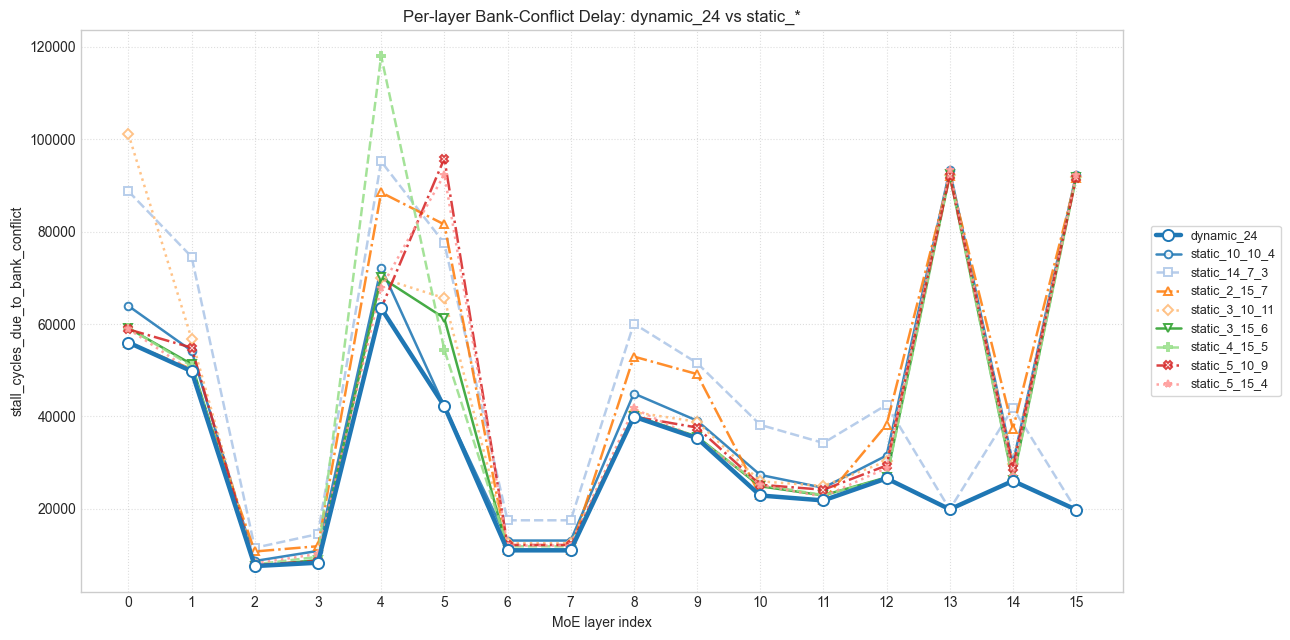

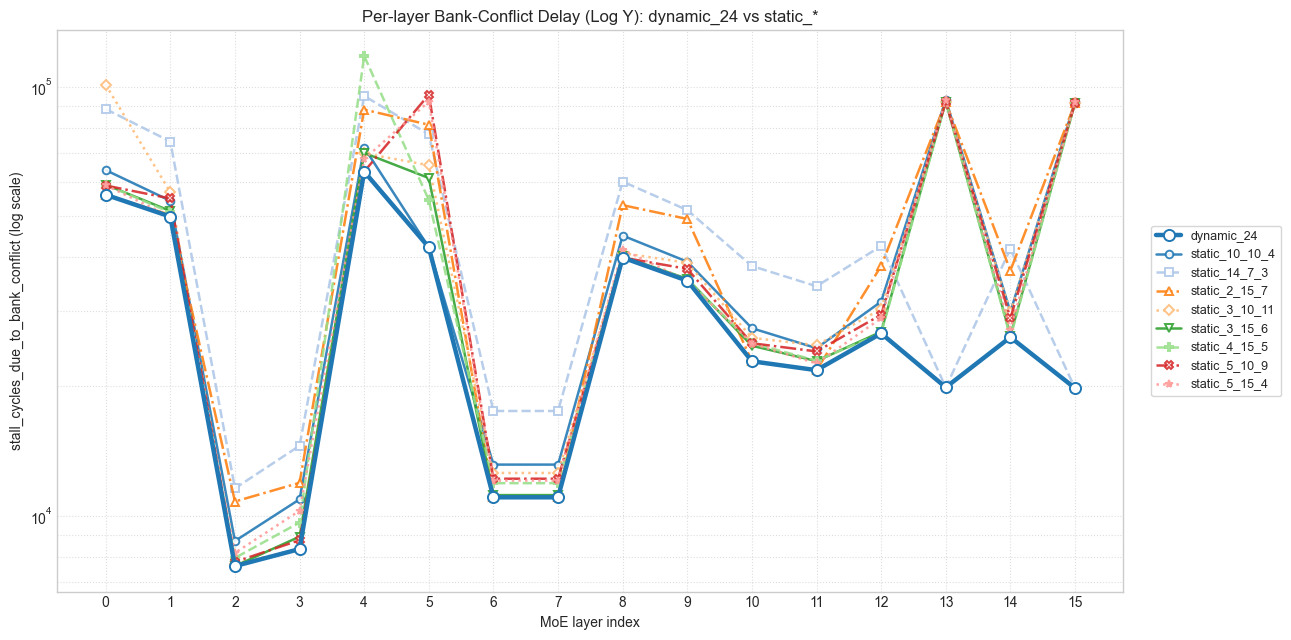

=== 每个方案在各 MoE 层的 bank 冲突延时 ===


run,dynamic_24,static_10_10_4,static_14_7_3,static_2_15_7,static_3_10_11,static_3_15_6,static_4_15_5,static_5_10_9,static_5_15_4
MoE_Idx,,,,,,,,,
0,55998,63909,88722,55998,101088,59103,59157,58833,58914
1,49788,54210,74526,50244,56778,51312,50928,54882,49788
2,7623,8721,11574,10782,7719,7623,7965,7794,8181
3,8352,10908,14544,11922,8352,8928,9630,8760,10260
4,63408,72144,95184,88464,69936,70080,118008,63408,67824
5,42216,42216,77454,81540,65598,61260,54438,95808,92340
6,11028,13146,17532,11028,12570,11160,11898,12186,12066
7,11028,13146,17532,11028,12570,11160,11898,12186,12066
8,39960,44964,60084,52956,40932,40194,40230,39960,41724


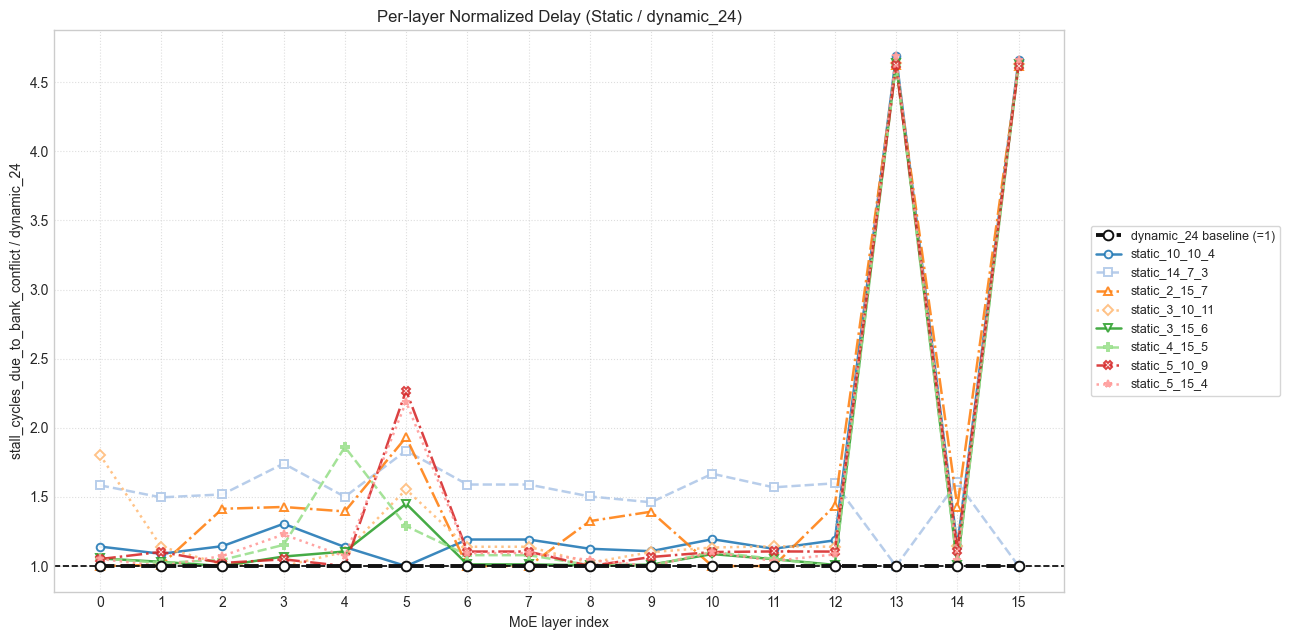

=== 归一化延时表（Static / dynamic_24）===


run,dynamic_24,static_10_10_4,static_14_7_3,static_2_15_7,static_3_10_11,static_3_15_6,static_4_15_5,static_5_10_9,static_5_15_4
MoE_Idx,,,,,,,,,
0,1.0,1.141273,1.584378,1.000000,1.805207,1.055448,1.056413,1.050627,1.052073
1,1.0,1.088817,1.496867,1.009159,1.140395,1.030610,1.022897,1.102314,1.000000
2,1.0,1.144038,1.518300,1.414404,1.012593,1.000000,1.044864,1.022432,1.073200
3,1.0,1.306034,1.741379,1.427443,1.000000,1.068966,1.153017,1.048851,1.228448
4,1.0,1.137774,1.501136,1.395155,1.102952,1.105223,1.861090,1.000000,1.069644
5,1.0,1.000000,1.834707,1.931495,1.553866,1.451109,1.289511,2.269471,2.187322
6,1.0,1.192057,1.589771,1.000000,1.139826,1.011970,1.078890,1.105005,1.094124
7,1.0,1.192057,1.589771,1.000000,1.139826,1.011970,1.078890,1.105005,1.094124
8,1.0,1.125225,1.503604,1.325225,1.024324,1.005856,1.006757,1.000000,1.044144


=== dynamic_24 相对各 static 的逐层收益（基于 stall_cycles_due_to_bank_conflict） ===


,MoE_Idx,static_run,dyn_vs_static_gain
0,0,static_10_10_4,0.123785
1,0,static_14_7_3,0.368837
2,0,static_2_15_7,0.000000
3,0,static_3_10_11,0.446047
4,0,static_3_15_6,0.052535
...,...,...,...
123,15,static_3_10_11,0.784047
124,15,static_3_15_6,0.784202
125,15,static_4_15_5,0.783523
126,15,static_5_10_9,0.783481


In [14]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 你指定的两个索引目录
DYNAMIC_RUN_DIR = "/home/MikeNotFound/code/SCALE-Sim/outputs/final4/dynamic_24"
STATIC_ROOT = "/home/MikeNotFound/code/SCALE-Sim/outputs/final4/dynamic_compare"
DYNAMIC_RUN = os.path.basename(DYNAMIC_RUN_DIR)

MOE_MIN, MOE_MAX = 0, 15  # 16层 MoE


def load_bank(run_dir: str) -> pd.DataFrame:
    bank_csv = os.path.join(run_dir, "BANK_MODEL_REPORT.csv")
    if not os.path.exists(bank_csv):
        raise FileNotFoundError(f"缺少文件: {bank_csv}")

    df = pd.read_csv(bank_csv)
    df.columns = df.columns.str.strip().str.rstrip(",")

    need_cols = [
        "LayerID",
        "allocation_ratio",
        "stall_cycles_due_to_bank_conflict",
    ]
    miss = [c for c in need_cols if c not in df.columns]
    if miss:
        raise RuntimeError(f"{run_dir} 缺少关键列: {miss}")

    for c in ["LayerID", "stall_cycles_due_to_bank_conflict"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 若是全网络报告，截取 MoE 16 层；若是 MoE-only 则直接全表
    moe = df[(df["LayerID"] >= MOE_MIN) & (df["LayerID"] <= MOE_MAX)].copy()
    if moe.empty:
        moe = df.copy()

    moe = moe.sort_values("LayerID").reset_index(drop=True)
    moe["MoE_Idx"] = np.arange(len(moe), dtype=int)

    return moe[
        [
            "MoE_Idx",
            "LayerID",
            "allocation_ratio",
            "stall_cycles_due_to_bank_conflict",
        ]
    ]


# ============================================================
# 1) 读取 dynamic_24 结果
# ============================================================

if not os.path.isdir(DYNAMIC_RUN_DIR):
    raise RuntimeError(f"目录不存在: {DYNAMIC_RUN_DIR}")

dyn = load_bank(DYNAMIC_RUN_DIR)
dyn["run"] = DYNAMIC_RUN


# ============================================================
# 2) 读取 dynamic_compare 下全部 static_* 方案
# ============================================================

if not os.path.isdir(STATIC_ROOT):
    raise RuntimeError(f"目录不存在: {STATIC_ROOT}")

static_dirs = sorted(
    [
        d
        for d in glob.glob(os.path.join(STATIC_ROOT, "static_*"))
        if os.path.isdir(d)
    ]
)

if not static_dirs:
    raise RuntimeError(f"未找到静态目录: {STATIC_ROOT}/static_*")

all_runs = [dyn]

for sd in static_dirs:
    run = os.path.basename(sd)
    s = load_bank(sd)
    s["run"] = run
    all_runs.append(s)

plot_df = pd.concat(all_runs, ignore_index=True)
plot_df = plot_df.sort_values(["run", "MoE_Idx"]).reset_index(drop=True)

static_runs = sorted(
    [
        r
        for r in plot_df["run"].unique().tolist()
        if r != DYNAMIC_RUN
    ]
)


# ============================================================
# 彩色 + 黑白打印友好样式
# 彩色打印：靠颜色区分
# 黑白打印：靠 linestyle + marker + 线宽区分
# ============================================================

cmap = plt.get_cmap("tab20")

line_styles = [
    "-",
    "--",
    "-.",
    ":",
]

markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P",
    "X",
    "*",
    "<",
    ">",
    "h",
    "p",
]

color_map = {
    run: cmap(i % 20)
    for i, run in enumerate(static_runs)
}

style_map = {}

for i, run in enumerate(static_runs):
    style_map[run] = {
        "color": color_map[run],
        "linestyle": line_styles[i % len(line_styles)],
        "marker": markers[i % len(markers)],
        "linewidth": 1.8,
        "markersize": 5.5,
        "alpha": 0.88,
        "zorder": 2,
    }

dynamic_style = {
    "color": "#1f77b4",
    "linestyle": "-",
    "marker": "o",
    "linewidth": 3.2,
    "markersize": 8,
    "alpha": 1.0,
    "zorder": 6,
}

baseline_style = {
    "color": "#111111",
    "linestyle": "--",
    "marker": "o",
    "linewidth": 2.8,
    "markersize": 7,
    "alpha": 1.0,
    "zorder": 6,
}


def plot_one_run(ax, x, y, run, label=None, is_dynamic=False):
    """
    统一绘图函数：
    - dynamic_24 加粗突出
    - static_* 使用颜色 + 线型 + marker 区分
    - marker 使用空心样式，黑白打印更清晰
    """
    if is_dynamic:
        st = dynamic_style
    else:
        st = style_map[run]

    ax.plot(
        x,
        y,
        color=st["color"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        linewidth=st["linewidth"],
        markersize=st["markersize"],
        markerfacecolor="white",
        markeredgecolor=st["color"],
        markeredgewidth=1.4,
        alpha=st["alpha"],
        label=label if label is not None else run,
        zorder=st["zorder"],
    )


# ============================================================
# 3) 线性坐标图：横轴 MoE 层，纵轴 bank 冲突导致的延时
# ============================================================

fig, ax = plt.subplots(figsize=(13, 6.5))

d = plot_df[plot_df["run"] == DYNAMIC_RUN].sort_values("MoE_Idx")

plot_one_run(
    ax,
    d["MoE_Idx"],
    d["stall_cycles_due_to_bank_conflict"],
    DYNAMIC_RUN,
    label=DYNAMIC_RUN,
    is_dynamic=True,
)

for run in static_runs:
    g = plot_df[plot_df["run"] == run].sort_values("MoE_Idx")

    plot_one_run(
        ax,
        g["MoE_Idx"],
        g["stall_cycles_due_to_bank_conflict"],
        run,
        label=run,
        is_dynamic=False,
    )

ax.set_title("Per-layer Bank-Conflict Delay: dynamic_24 vs static_*")
ax.set_xlabel("MoE layer index")
ax.set_ylabel("stall_cycles_due_to_bank_conflict")
ax.set_xticks(sorted(plot_df["MoE_Idx"].unique().tolist()))
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True,
)
plt.tight_layout()
plt.show()


# ============================================================
# 4) 对数纵轴图
# 注意：log 坐标不能显示 <=0 的点，因此这里将 <=0 替换为 NaN
# ============================================================

fig, ax = plt.subplots(figsize=(13, 6.5))

d_log = d.copy()
d_log.loc[
    d_log["stall_cycles_due_to_bank_conflict"] <= 0,
    "stall_cycles_due_to_bank_conflict",
] = np.nan

plot_one_run(
    ax,
    d_log["MoE_Idx"],
    d_log["stall_cycles_due_to_bank_conflict"],
    DYNAMIC_RUN,
    label=DYNAMIC_RUN,
    is_dynamic=True,
)

for run in static_runs:
    g = plot_df[plot_df["run"] == run].sort_values("MoE_Idx").copy()
    g.loc[
        g["stall_cycles_due_to_bank_conflict"] <= 0,
        "stall_cycles_due_to_bank_conflict",
    ] = np.nan

    plot_one_run(
        ax,
        g["MoE_Idx"],
        g["stall_cycles_due_to_bank_conflict"],
        run,
        label=run,
        is_dynamic=False,
    )

ax.set_yscale("log")
ax.set_title("Per-layer Bank-Conflict Delay (Log Y): dynamic_24 vs static_*")
ax.set_xlabel("MoE layer index")
ax.set_ylabel("stall_cycles_due_to_bank_conflict (log scale)")
ax.set_xticks(sorted(plot_df["MoE_Idx"].unique().tolist()))
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65, which="both")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True,
)
plt.tight_layout()
plt.show()


# ============================================================
# 5) 输出原始透视表
# ============================================================

print("=== 每个方案在各 MoE 层的 bank 冲突延时 ===")

pivot_delay = (
    plot_df.pivot(
        index="MoE_Idx",
        columns="run",
        values="stall_cycles_due_to_bank_conflict",
    )
    .sort_index()
)

display(pivot_delay)


# ============================================================
# 6) 归一化图：每条静态曲线除以 dynamic_24
# >1 表示比 dynamic_24 更差
# ============================================================

norm = pivot_delay.div(pivot_delay[DYNAMIC_RUN], axis=0)

fig, ax = plt.subplots(figsize=(13, 6.5))

ax.plot(
    norm.index,
    np.ones(len(norm.index)),
    color=baseline_style["color"],
    linestyle=baseline_style["linestyle"],
    marker=baseline_style["marker"],
    linewidth=baseline_style["linewidth"],
    markersize=baseline_style["markersize"],
    markerfacecolor="white",
    markeredgecolor=baseline_style["color"],
    markeredgewidth=1.4,
    label=f"{DYNAMIC_RUN} baseline (=1)",
    zorder=baseline_style["zorder"],
)

for run in static_runs:
    plot_one_run(
        ax,
        norm.index,
        norm[run],
        run,
        label=run,
        is_dynamic=False,
    )

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

ax.set_title("Per-layer Normalized Delay (Static / dynamic_24)")
ax.set_xlabel("MoE layer index")
ax.set_ylabel("stall_cycles_due_to_bank_conflict / dynamic_24")
ax.set_xticks(norm.index.tolist())
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True,
)
plt.tight_layout()
plt.show()

print("=== 归一化延时表（Static / dynamic_24）===")
display(norm)


# ============================================================
# 7) dynamic_24 相对每个 static 的逐层收益
# 正值表示 dynamic_24 更小
# ============================================================

if not static_runs:
    print("没有静态方案可比较。")
else:
    gain_records = []
    dyn_series = pivot_delay[DYNAMIC_RUN]

    for s in static_runs:
        common = pd.concat(
            [
                dyn_series,
                pivot_delay[s],
            ],
            axis=1,
            keys=["dyn", "st"],
        ).dropna()

        for idx, row in common.iterrows():
            gain = (
                (row["st"] - row["dyn"]) / row["st"]
                if row["st"] > 0
                else np.nan
            )

            gain_records.append(
                {
                    "MoE_Idx": int(idx),
                    "static_run": s,
                    "dyn_vs_static_gain": gain,
                }
            )

    gain_df = (
        pd.DataFrame(gain_records)
        .sort_values(["MoE_Idx", "static_run"])
        .reset_index(drop=True)
    )

    print("=== dynamic_24 相对各 static 的逐层收益（基于 stall_cycles_due_to_bank_conflict） ===")
    display(gain_df)

=== MoE-only 端到端汇总（固定16层MoE）===


,run,group,strategy,bw_bits,ports,moe_layers,moe_total_cycles,moe_stall_cycles,moe_stall_ratio,moe_conflict_stall,moe_conflict_stall_share,moe_conflict_delay,avg_bank_imbalance,avg_total_sram_bw,avg_total_dram_bw,norm_vs_dynamic24
0,dynamic_24,baseline,Dynamic,NaN,NaN,16,781811,461787,0.590663,461787,1.0,10353438,6.607031,14.855493,0.0,1.000000
1,static_8_8_8,baseline,Static,NaN,NaN,16,1870007,1549983,0.828865,1549983,1.0,37212777,10.603271,6.226589,0.0,2.391891
2,dynamic_24_128bit,bw,Dynamic,128.0,NaN,16,781811,461787,0.590663,461787,1.0,10353438,6.607031,14.855493,0.0,1.000000
3,dynamic_24_32bit,bw,Dynamic,32.0,NaN,16,1622957,1302933,0.802814,1302933,1.0,30540123,7.146429,7.197272,0.0,2.075894
4,dynamic_24_64bit,bw,Dynamic,64.0,NaN,16,1069370,749346,0.700736,749346,1.0,23957829,7.338614,10.799399,0.0,1.367811
5,static_8_8_8_128bit,bw,Static,128.0,NaN,16,1870007,1549983,0.828865,1549983,1.0,37212777,10.603271,6.226589,0.0,2.391891
6,static_8_8_8_32bit,bw,Static,32.0,NaN,16,6497318,6177294,0.950745,6177294,1.0,181149603,10.603271,1.790720,0.0,8.310599
7,static_8_8_8_64bit,bw,Static,64.0,NaN,16,3385928,3065904,0.905484,3065904,1.0,84568650,10.603271,3.441691,0.0,4.330878
8,dynamic_24_1port,port,Dynamic,NaN,1.0,16,781811,461787,0.590663,461787,1.0,10353438,6.607031,14.855493,0.0,1.000000
9,dynamic_24_2port,port,Dynamic,NaN,2.0,16,420032,100008,0.238096,100008,1.0,1273974,8.019073,27.557457,0.0,0.537255


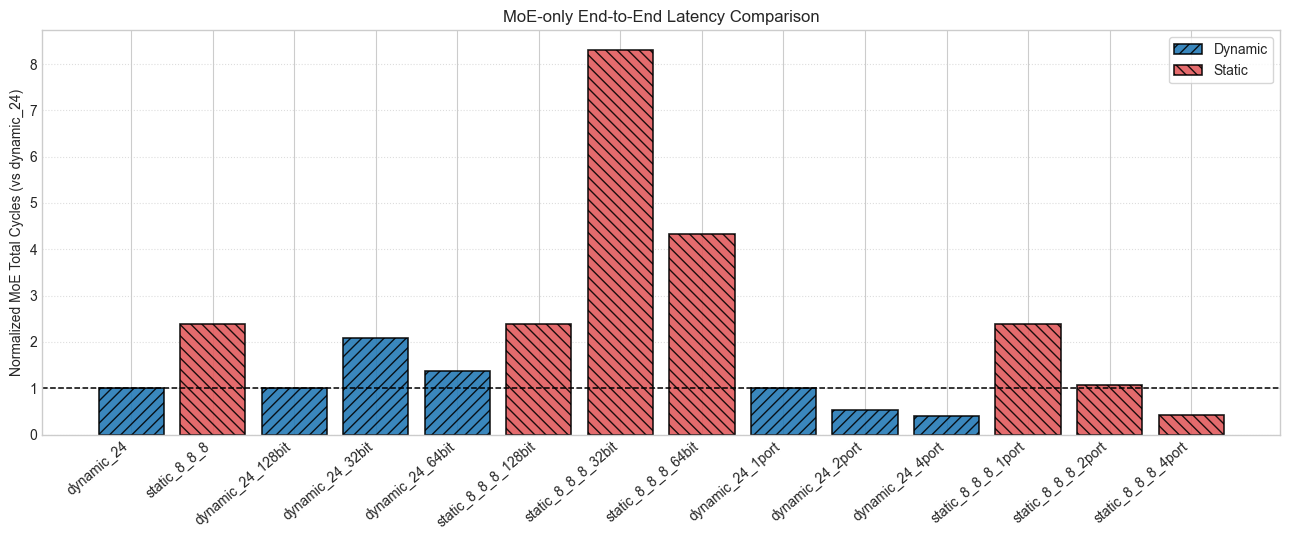

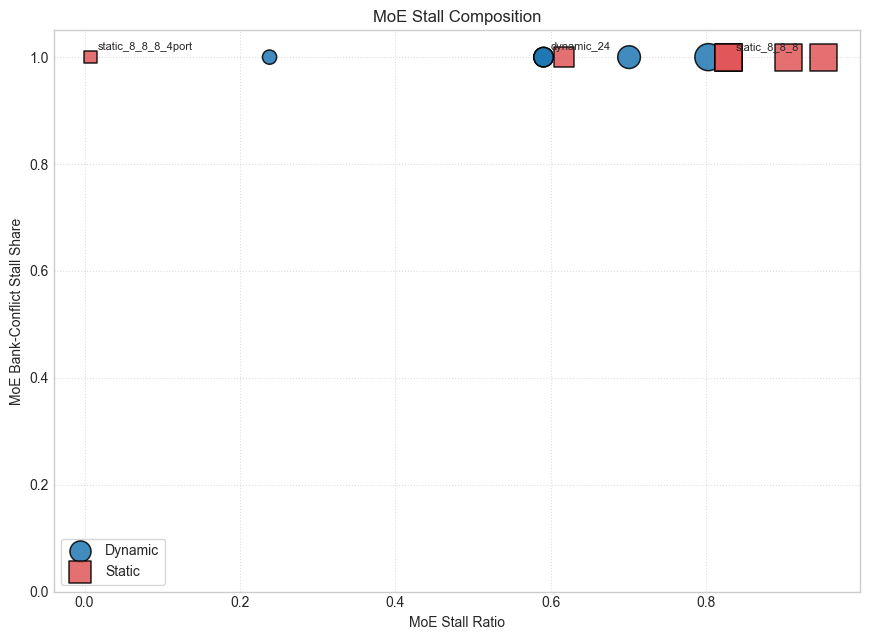

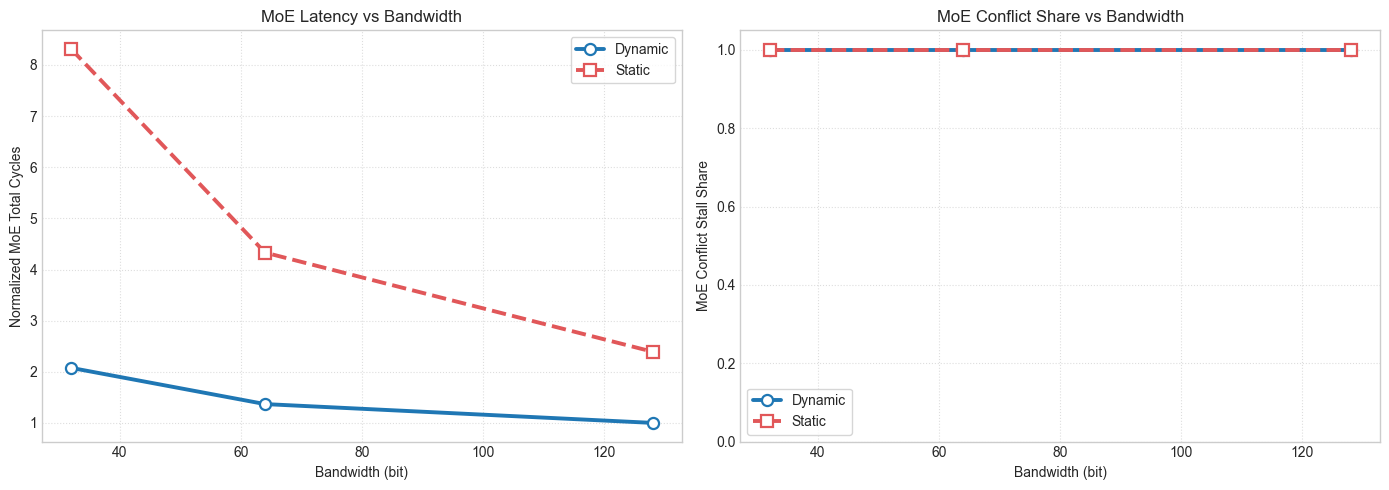

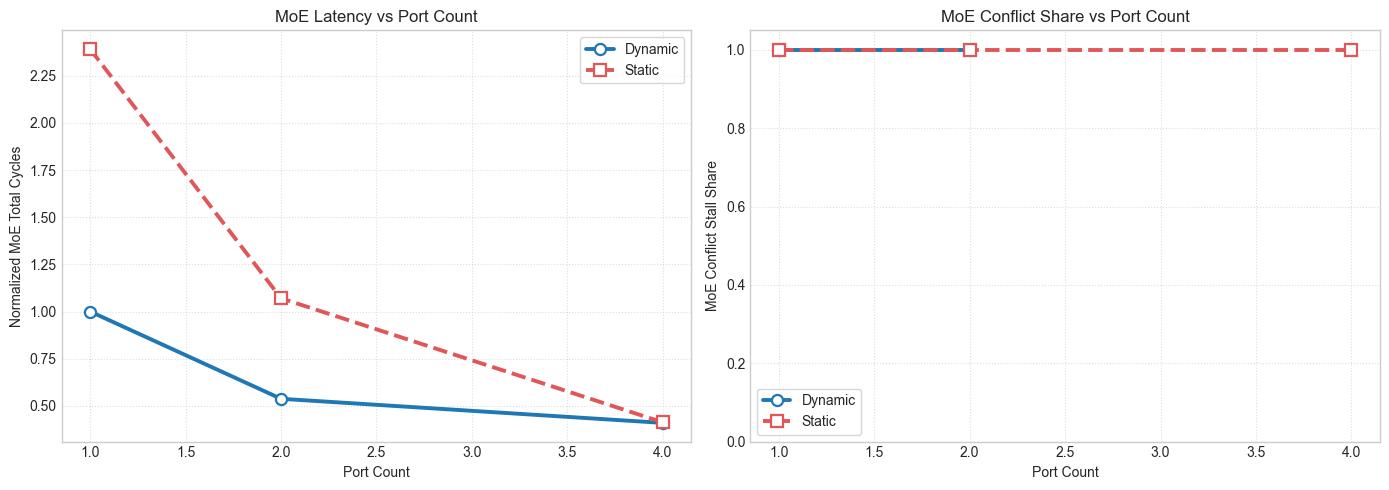

=== 带宽组诊断表（MoE）===


,setting,dynamic_moe_total_cycles,static_moe_total_cycles,dynamic_minus_static
0,32bit,1622957.0,6497318.0,-4874361.0
1,64bit,1069370.0,3385928.0,-2316558.0
2,128bit,781811.0,1870007.0,-1088196.0



=== 自动结论（MoE-only）===
MoE最小时延: dynamic_24_4port
MoE最大时延: static_8_8_8_32bit
baseline(dynamic_24 vs static_8_8_8) MoE时延收益: 58.19%
128bit 行由 baseline(dynamic_24/static_8_8_8) 别名映射得到。
dynamic 在 32->64bit 的 MoE总周期变化: -553587


In [15]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 数据源 ======
ROOT = "/home/MikeNotFound/code/SCALE-Sim/outputs/final4"
RUNS = {
    "dynamic_24": os.path.join(ROOT, "dynamic_24"),
    "static_8_8_8": os.path.join(ROOT, "static_8_8_8"),

    # 默认配置别名：dynamic_24 == dynamic_24_128bit == dynamic_24_1port
    "dynamic_24_128bit": os.path.join(ROOT, "dynamic_24"),
    "static_8_8_8_128bit": os.path.join(ROOT, "static_8_8_8"),
    "dynamic_24_1port": os.path.join(ROOT, "dynamic_24"),
    "static_8_8_8_1port": os.path.join(ROOT, "static_8_8_8"),

    "dynamic_24_32bit": os.path.join(ROOT, "end2end", "bw", "dynamic_24_32bit"),
    "dynamic_24_64bit": os.path.join(ROOT, "end2end", "bw", "dynamic_24_64bit"),
    "static_8_8_8_32bit": os.path.join(ROOT, "end2end", "bw", "static_8_8_8_32bit"),
    "static_8_8_8_64bit": os.path.join(ROOT, "end2end", "bw", "static_8_8_8_64bit"),

    "dynamic_24_2port": os.path.join(ROOT, "end2end", "port", "dynamic_24_2port"),
    "dynamic_24_4port": os.path.join(ROOT, "end2end", "port", "dynamic_24_4port"),
    "static_8_8_8_2port": os.path.join(ROOT, "end2end", "port", "static_8_8_8_2port"),
    "static_8_8_8_4port": os.path.join(ROOT, "end2end", "port", "static_8_8_8_4port"),
}

EXPECTED_MOE = 16
FULL_MODEL_MOE_MIN, FULL_MODEL_MOE_MAX = 7, 22


# ============================================================
# 彩色 + 黑白打印友好样式
# 彩色打印：靠 color 区分
# 黑白打印：靠 linestyle / marker / hatch / edge 区分
# ============================================================

STYLE = {
    "Dynamic": {
        "color": "#1f77b4",
        "linestyle": "-",
        "marker": "o",
        "hatch": "///",
        "linewidth": 2.8,
        "markersize": 8,
    },
    "Static": {
        "color": "#e15759",
        "linestyle": "--",
        "marker": "s",
        "hatch": "\\\\\\",
        "linewidth": 2.8,
        "markersize": 8,
    },
}

GROUP_STYLE = {
    "baseline": {
        "edgecolor": "black",
        "linewidth": 1.2,
    },
    "bw": {
        "edgecolor": "black",
        "linewidth": 1.2,
    },
    "port": {
        "edgecolor": "black",
        "linewidth": 1.2,
    },
}


def _clean_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = out.columns.str.strip().str.rstrip(",")
    if "Unnamed: 33" in out.columns:
        out = out.drop(columns=["Unnamed: 33"])
    return out


def _to_numeric(df: pd.DataFrame, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def _strategy_from_name(name: str) -> str:
    return "Dynamic" if name.startswith("dynamic_24") else "Static"


def _group_from_name(name: str) -> str:
    if "bit" in name:
        return "bw"
    if "port" in name:
        return "port"
    return "baseline"


def _extract_bw_or_port(name: str):
    bit_match = re.search(r"_(\d+)bit$", name)
    port_match = re.search(r"_(\d+)port$", name)

    bw_bits = int(bit_match.group(1)) if bit_match else np.nan
    ports = int(port_match.group(1)) if port_match else np.nan

    return bw_bits, ports


def _extract_moe_rows(df: pd.DataFrame, layer_col: str = "LayerID") -> pd.DataFrame:
    if layer_col not in df.columns:
        raise RuntimeError("报告缺少 LayerID，无法提取 MoE 层")

    src = df.copy()
    src[layer_col] = pd.to_numeric(src[layer_col], errors="coerce")
    src = src.dropna(subset=[layer_col]).copy()
    src[layer_col] = src[layer_col].astype(int)

    # Case A: 全网络报告，MoE 为 7..22
    full = src[
        (src[layer_col] >= FULL_MODEL_MOE_MIN)
        & (src[layer_col] <= FULL_MODEL_MOE_MAX)
    ].copy()

    if len(full) == EXPECTED_MOE:
        out = full.sort_values(layer_col).reset_index(drop=True)
        out["MoE_Idx"] = np.arange(len(out), dtype=int)
        return out

    # Case B: 已经是 MoE-only，LayerID 0..15 或恰好 16 层
    ids = sorted(src[layer_col].unique().tolist())

    if len(ids) == EXPECTED_MOE and ids[0] == 0 and ids[-1] == EXPECTED_MOE - 1:
        out = src.sort_values(layer_col).reset_index(drop=True)
        out["MoE_Idx"] = np.arange(len(out), dtype=int)
        return out

    if len(src) == EXPECTED_MOE:
        out = src.sort_values(layer_col).reset_index(drop=True)
        out["MoE_Idx"] = np.arange(len(out), dtype=int)
        return out

    raise RuntimeError(
        f"无法稳定提取 16 层 MoE，LayerID={ids[:6]}..."
        f"{ids[-6:] if len(ids) > 6 else ids}, 行数={len(src)}"
    )


def _safe_div(a, b):
    return a / b if np.isfinite(a) and np.isfinite(b) and b != 0 else np.nan


def _load_and_summarize(run_name: str, run_dir: str) -> dict:
    comp_csv = os.path.join(run_dir, "COMPUTE_REPORT.csv")
    bank_csv = os.path.join(run_dir, "BANK_MODEL_REPORT.csv")
    bw_csv = os.path.join(run_dir, "BANDWIDTH_REPORT.csv")

    for fp in [comp_csv, bank_csv, bw_csv]:
        if not os.path.exists(fp):
            raise FileNotFoundError(f"{run_name} 缺少文件: {fp}")

    comp = _clean_cols(pd.read_csv(comp_csv))
    bank = _clean_cols(pd.read_csv(bank_csv))
    bw = _clean_cols(pd.read_csv(bw_csv))

    comp = _to_numeric(
        comp,
        [
            "LayerID",
            "Total Cycles",
            "Stall Cycles",
            "Compute Util %",
            "Overall Util %",
        ],
    )

    bank = _to_numeric(
        bank,
        [
            "LayerID",
            "total_cycles",
            "stall_cycles_due_to_bank_conflict",
            "total_bank_conflict_delay",
            "ifmap_capacity_utilization",
            "filter_capacity_utilization",
            "ofmap_capacity_utilization",
        ],
    )

    bw = _to_numeric(
        bw,
        [
            "LayerID",
            "Avg IFMAP SRAM BW",
            "Avg FILTER SRAM BW",
            "Avg OFMAP SRAM BW",
            "Avg IFMAP DRAM BW",
            "Avg FILTER DRAM BW",
            "Avg OFMAP DRAM BW",
        ],
    )

    comp_moe = _extract_moe_rows(comp, layer_col="LayerID")
    bank_moe = _extract_moe_rows(bank, layer_col="LayerID")
    bw_moe = _extract_moe_rows(bw, layer_col="LayerID")

    if (
        len(comp_moe) != EXPECTED_MOE
        or len(bank_moe) != EXPECTED_MOE
        or len(bw_moe) != EXPECTED_MOE
    ):
        raise RuntimeError(f"{run_name} MoE 提取后层数不是 16")

    # MoE 汇总
    total_cycles = comp_moe["Total Cycles"].sum()
    stall_cycles = comp_moe["Stall Cycles"].sum()
    stall_ratio = _safe_div(stall_cycles, total_cycles)

    conflict_stall = bank_moe["stall_cycles_due_to_bank_conflict"].sum()
    conflict_share = _safe_div(conflict_stall, stall_cycles)
    conflict_delay = bank_moe["total_bank_conflict_delay"].sum()

    util_cols = [
        "ifmap_capacity_utilization",
        "filter_capacity_utilization",
        "ofmap_capacity_utilization",
    ]

    if all(c in bank_moe.columns for c in util_cols):
        bank_imbalance = (
            bank_moe[util_cols].max(axis=1)
            - bank_moe[util_cols].min(axis=1)
        ).mean()
    else:
        bank_imbalance = np.nan

    sram_cols = [
        "Avg IFMAP SRAM BW",
        "Avg FILTER SRAM BW",
        "Avg OFMAP SRAM BW",
    ]

    dram_cols = [
        "Avg IFMAP DRAM BW",
        "Avg FILTER DRAM BW",
        "Avg OFMAP DRAM BW",
    ]

    avg_sram_bw = (
        bw_moe[sram_cols].sum(axis=1).mean()
        if all(c in bw_moe.columns for c in sram_cols)
        else np.nan
    )

    avg_dram_bw = (
        bw_moe[dram_cols].sum(axis=1).mean()
        if all(c in bw_moe.columns for c in dram_cols)
        else np.nan
    )

    strategy = _strategy_from_name(run_name)
    group = _group_from_name(run_name)
    bw_bits, ports = _extract_bw_or_port(run_name)

    return {
        "run": run_name,
        "group": group,
        "strategy": strategy,
        "bw_bits": bw_bits,
        "ports": ports,
        "moe_layers": int(len(comp_moe)),
        "moe_total_cycles": total_cycles,
        "moe_stall_cycles": stall_cycles,
        "moe_stall_ratio": stall_ratio,
        "moe_conflict_stall": conflict_stall,
        "moe_conflict_stall_share": conflict_share,
        "moe_conflict_delay": conflict_delay,
        "avg_bank_imbalance": bank_imbalance,
        "avg_total_sram_bw": avg_sram_bw,
        "avg_total_dram_bw": avg_dram_bw,
    }


def plot_strategy_line(ax, x, y, strategy, label=None):
    st = STYLE[strategy]

    ax.plot(
        x,
        y,
        color=st["color"],
        linestyle=st["linestyle"],
        marker=st["marker"],
        linewidth=st["linewidth"],
        markersize=st["markersize"],
        markerfacecolor="white",
        markeredgecolor=st["color"],
        markeredgewidth=1.6,
        label=label if label is not None else strategy,
    )


records = []

for run, path in RUNS.items():
    records.append(_load_and_summarize(run, path))

res = (
    pd.DataFrame(records)
    .sort_values(["group", "strategy", "run"])
    .reset_index(drop=True)
)

dyn_ref = res.loc[res["run"] == "dynamic_24", "moe_total_cycles"].iloc[0]
res["norm_vs_dynamic24"] = res["moe_total_cycles"] / dyn_ref

print("=== MoE-only 端到端汇总（固定16层MoE）===")

display(
    res[
        [
            "run",
            "group",
            "strategy",
            "bw_bits",
            "ports",
            "moe_layers",
            "moe_total_cycles",
            "moe_stall_cycles",
            "moe_stall_ratio",
            "moe_conflict_stall",
            "moe_conflict_stall_share",
            "moe_conflict_delay",
            "avg_bank_imbalance",
            "avg_total_sram_bw",
            "avg_total_dram_bw",
            "norm_vs_dynamic24",
        ]
    ]
)


# ============================================================
# 图1: MoE总周期归一化
# 彩色 + hatch，黑白打印也能区分 Dynamic / Static
# ============================================================

plot_df = (
    res.sort_values(["group", "strategy", "run"])
    .reset_index(drop=True)
)

x = np.arange(len(plot_df))

plt.figure(figsize=(13, 5.5))
ax = plt.gca()

for i, row in plot_df.iterrows():
    st = STYLE[row["strategy"]]

    ax.bar(
        i,
        row["norm_vs_dynamic24"],
        color=st["color"],
        edgecolor="black",
        linewidth=1.2,
        hatch=st["hatch"],
        alpha=0.88,
        label=row["strategy"] if row["strategy"] not in ax.get_legend_handles_labels()[1] else None,
    )

ax.axhline(
    1.0,
    linestyle="--",
    color="black",
    linewidth=1.1,
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["run"],
    rotation=40,
    ha="right",
)

ax.set_ylabel("Normalized MoE Total Cycles (vs dynamic_24)")
ax.set_title("MoE-only End-to-End Latency Comparison")
ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.65)
ax.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()


# ============================================================
# 图2: stall构成散点图
# 彩色 + marker 形状区分，黑白打印可辨
# ============================================================

plt.figure(figsize=(8.8, 6.5))
ax = plt.gca()

for strategy, g in res.groupby("strategy"):
    st = STYLE[strategy]

    size_base = g["moe_total_cycles"].min()
    sizes = np.clip(
        g["moe_total_cycles"] / size_base * 80,
        60,
        380,
    )

    ax.scatter(
        g["moe_stall_ratio"],
        g["moe_conflict_stall_share"],
        s=sizes,
        color=st["color"],
        marker=st["marker"],
        alpha=0.85,
        edgecolors="black",
        linewidths=1.1,
        label=strategy,
    )

for _, r in res.iterrows():
    if r["run"] in [
        "dynamic_24",
        "static_8_8_8",
        "dynamic_24_4port",
        "static_8_8_8_4port",
    ]:
        ax.annotate(
            r["run"],
            (
                r["moe_stall_ratio"],
                r["moe_conflict_stall_share"],
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

ax.set_xlabel("MoE Stall Ratio")
ax.set_ylabel("MoE Bank-Conflict Stall Share")
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65)
ax.set_title("MoE Stall Composition")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()


# ============================================================
# 图3: 带宽组
# 彩色 + 线型 + marker 区分
# ============================================================

bw_df = (
    res[res["group"] == "bw"]
    .copy()
    .sort_values(["strategy", "bw_bits"])
)

if not bw_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for strategy, g in bw_df.groupby("strategy"):
        g = g.sort_values("bw_bits")

        plot_strategy_line(
            axes[0],
            g["bw_bits"],
            g["norm_vs_dynamic24"],
            strategy,
            label=strategy,
        )

        plot_strategy_line(
            axes[1],
            g["bw_bits"],
            g["moe_conflict_stall_share"],
            strategy,
            label=strategy,
        )

    axes[0].set_title("MoE Latency vs Bandwidth")
    axes[0].set_xlabel("Bandwidth (bit)")
    axes[0].set_ylabel("Normalized MoE Total Cycles")
    axes[0].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)

    axes[1].set_title("MoE Conflict Share vs Bandwidth")
    axes[1].set_xlabel("Bandwidth (bit)")
    axes[1].set_ylabel("MoE Conflict Stall Share")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)

    for ax in axes:
        ax.legend(frameon=True)

    plt.tight_layout()
    plt.show()


# ============================================================
# 图4: Port组
# 彩色 + 线型 + marker 区分
# ============================================================

port_df = (
    res[res["group"] == "port"]
    .copy()
    .sort_values(["strategy", "ports"])
)

if not port_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for strategy, g in port_df.groupby("strategy"):
        g = g.sort_values("ports")

        plot_strategy_line(
            axes[0],
            g["ports"],
            g["norm_vs_dynamic24"],
            strategy,
            label=strategy,
        )

        plot_strategy_line(
            axes[1],
            g["ports"],
            g["moe_conflict_stall_share"],
            strategy,
            label=strategy,
        )

    axes[0].set_title("MoE Latency vs Port Count")
    axes[0].set_xlabel("Port Count")
    axes[0].set_ylabel("Normalized MoE Total Cycles")
    axes[0].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)

    axes[1].set_title("MoE Conflict Share vs Port Count")
    axes[1].set_xlabel("Port Count")
    axes[1].set_ylabel("MoE Conflict Stall Share")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, linestyle=":", linewidth=0.8, alpha=0.65)

    for ax in axes:
        ax.legend(frameon=True)

    plt.tight_layout()
    plt.show()


# ============================================================
# 关键差值表：检查“带宽无影响”
# ============================================================

def _pair_delta(df, key_col, dynamic_name, static_name):
    d = df[df["run"] == dynamic_name]
    s = df[df["run"] == static_name]

    if d.empty or s.empty:
        return np.nan

    return float(d.iloc[0][key_col] - s.iloc[0][key_col])


bw_diag = []

for bits in [32, 64, 128]:
    dname = f"dynamic_24_{bits}bit"
    sname = f"static_8_8_8_{bits}bit"

    drow = res[res["run"] == dname]
    srow = res[res["run"] == sname]

    if drow.empty or srow.empty:
        continue

    bw_diag.append(
        {
            "setting": f"{bits}bit",
            "dynamic_moe_total_cycles": float(drow.iloc[0]["moe_total_cycles"]),
            "static_moe_total_cycles": float(srow.iloc[0]["moe_total_cycles"]),
            "dynamic_minus_static": float(
                drow.iloc[0]["moe_total_cycles"]
                - srow.iloc[0]["moe_total_cycles"]
            ),
        }
    )

bw_diag_df = pd.DataFrame(bw_diag)

print("=== 带宽组诊断表（MoE）===")
display(bw_diag_df)


# ============================================================
# 自动结论
# ============================================================

print("\n=== 自动结论（MoE-only）===")

best_run = res.loc[res["moe_total_cycles"].idxmin(), "run"]
worst_run = res.loc[res["moe_total_cycles"].idxmax(), "run"]

print(f"MoE最小时延: {best_run}")
print(f"MoE最大时延: {worst_run}")

base_dyn = res[res["run"] == "dynamic_24"].iloc[0]["moe_total_cycles"]
base_sta = res[res["run"] == "static_8_8_8"].iloc[0]["moe_total_cycles"]

print(
    f"baseline(dynamic_24 vs static_8_8_8) MoE时延收益: "
    f"{(base_sta - base_dyn) / base_sta:.2%}"
)

if len(bw_diag_df) >= 2:
    base_128 = bw_diag_df[bw_diag_df["setting"] == "128bit"]

    if not base_128.empty:
        print("128bit 行由 baseline(dynamic_24/static_8_8_8) 别名映射得到。")

    diff32 = (
        bw_diag_df[bw_diag_df["setting"] == "32bit"]["dynamic_moe_total_cycles"].iloc[0]
        if (bw_diag_df["setting"] == "32bit").any()
        else np.nan
    )

    diff64 = (
        bw_diag_df[bw_diag_df["setting"] == "64bit"]["dynamic_moe_total_cycles"].iloc[0]
        if (bw_diag_df["setting"] == "64bit").any()
        else np.nan
    )

    if np.isfinite(diff32) and np.isfinite(diff64):
        print(f"dynamic 在 32->64bit 的 MoE总周期变化: {diff64 - diff32:.0f}")